# 02 Analysis and Figure Generation

This notebook calculates rainfall climatology, annual and seasonal rainfall indices, trend summaries, and manuscript figures for the PAGASA Science Garden rainfall trend analysis.

This notebook uses the prepared daily dataset generated by `01_data_preparation.ipynb`.

Main outputs:

1. Monthly rainfall climatology and TC-proximity rainfall fractions.
2. Annual rainfall indices and trends.
3. November–April seasonal rainfall indices and trends.
4. May–October seasonal rainfall indices and trends.
5. Manuscript figures and tables.
6. Supplementary trend and sensitivity outputs.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import linregress, norm, t

In [2]:
PROJECT_DIR = Path(".").resolve()

OUTPUT_DIR = PROJECT_DIR / "output"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
INTERMEDIATE_DIR = OUTPUT_DIR / "intermediate"

SUPP_FIGURE_DIR = FIGURE_DIR / "supplementary"
SUPP_TABLE_DIR = TABLE_DIR / "supplementary"

for path in [FIGURE_DIR, TABLE_DIR, SUPP_FIGURE_DIR, SUPP_TABLE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

PREPARED_PKL_PATH = INTERMEDIATE_DIR / "science_garden_daily_prepared.pkl"
PREPARED_CSV_PATH = INTERMEDIATE_DIR / "science_garden_daily_prepared.csv"

# Main manuscript figures
FIGURE_01_PATH = FIGURE_DIR / "figure_01_climatology.png"
FIGURE_02_PATH = FIGURE_DIR / "figure_02_annual_trends.png"
FIGURE_03_PATH = FIGURE_DIR / "figure_03_nov_apr_trends.png"
FIGURE_04_PATH = FIGURE_DIR / "figure_04_may_oct_trends.png"

# Main manuscript tables
TABLE_01_PATH = TABLE_DIR / "table_01_index_definitions.csv"
TABLE_02_PATH = TABLE_DIR / "table_02_selected_trends.csv"

# Supplementary outputs
SUPP_TABLE_S1_PATH = SUPP_TABLE_DIR / "supplementary_table_s1_full_trends.csv"

In [3]:
# -----------------------------
# Station and data settings
# -----------------------------
SCI_GARDEN_LAT = 14.65
SCI_GARDEN_LON = 121.05

CLIM_START = 1991
CLIM_END = 2020

WET_DAY_THRESHOLD = 1.0
MIN_VALID_FRACTION = 0.90

TC_FILTER_COL = "tc_1000km"

# -----------------------------
# Seasonal definitions
# -----------------------------
# Type I-style split based on Science Garden climatology
DRY_MONTHS = [11, 12, 1, 2, 3, 4]
WET_MONTHS = [5, 6, 7, 8, 9, 10]

DRY_SEASON_LABEL = "Nov-Apr"
WET_SEASON_LABEL = "May-Oct"

SEASON_ORDER = [DRY_SEASON_LABEL, WET_SEASON_LABEL]

# -----------------------------
# Plot settings
# -----------------------------
FIGURE_DPI = 300

PANEL_WIDTH = 3.3
PANEL_HEIGHT = 2.25

ROLLING_WINDOW = 10
SHOW_RUNNING_MEAN = True

MONTH_LABELS = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

In [4]:
INDEX_METADATA = {
    "PRCPTOT": {
        "name": "Wet-day rainfall total",
        "unit": "mm",
        "definition": "Total rainfall from wet days, where wet days are defined as rainfall >= 1.0 mm.",
        "interpretation": "Seasonal or annual rainfall accumulation from wet days.",
    },
    "WD": {
        "name": "Wet days",
        "unit": "days",
        "definition": "Number of days with rainfall >= 1.0 mm.",
        "interpretation": "Rainfall occurrence frequency.",
    },
    "WD_RATE": {
        "name": "Wet-day fraction",
        "unit": "fraction",
        "definition": "Wet days divided by eligible valid days.",
        "interpretation": "Fraction of valid days with rainfall >= 1.0 mm.",
    },
    "SDII": {
        "name": "Simple daily intensity index",
        "unit": "mm wet-day-1",
        "definition": "Wet-day rainfall total divided by number of wet days.",
        "interpretation": "Mean rainfall intensity on wet days.",
    },
    "R20mm": {
        "name": "Heavy precipitation days",
        "unit": "days",
        "definition": "Number of days with rainfall >= 20 mm.",
        "interpretation": "ETCCDI heavy precipitation day frequency.",
    },
    "R50mm": {
        "name": "Days with rainfall >= 50 mm",
        "unit": "days",
        "definition": "Number of days with rainfall >= 50 mm.",
        "interpretation": "Moderate-heavy rainfall frequency using a fixed local threshold.",
    },
    "R100mm": {
        "name": "Days with rainfall >= 100 mm",
        "unit": "days",
        "definition": "Number of days with rainfall >= 100 mm.",
        "interpretation": "Very heavy daily rainfall frequency.",
    },
    "RX1day": {
        "name": "Maximum 1-day rainfall",
        "unit": "mm",
        "definition": "Maximum daily rainfall within the period.",
        "interpretation": "Largest single-day rainfall total.",
    },
    "RX5day": {
        "name": "Maximum 5-day rainfall",
        "unit": "mm",
        "definition": "Maximum consecutive 5-day rainfall total within the period.",
        "interpretation": "Largest multi-day rainfall accumulation.",
    },
    "CDD": {
        "name": "Maximum consecutive dry days",
        "unit": "days",
        "definition": "Maximum number of consecutive days with rainfall < 1.0 mm.",
        "interpretation": "Dry-spell persistence.",
    },
    "DD_RATE": {
        "name": "Dry-day fraction",
        "unit": "fraction",
        "definition": "Dry days divided by eligible valid days.",
        "interpretation": "Fraction of valid days with rainfall < 1.0 mm.",
    },
    "MEAN_DRY_SPELL_LENGTH": {
        "name": "Mean dry-spell length",
        "unit": "days",
        "definition": "Mean length of consecutive dry-day runs.",
        "interpretation": "Typical dry-spell duration.",
    },
    "TOTAL_DRY_SPELL_DAYS_GE7": {
        "name": "Total days in dry spells >= 7 days",
        "unit": "days",
        "definition": "Total number of days belonging to dry spells lasting at least 7 days.",
        "interpretation": "Cumulative seasonal exposure to prolonged dry spells.",
    },
}

# Main manuscript figure indices
FIGURE_02_INDICES = ["PRCPTOT", "WD", "R20mm", "R50mm", "RX1day"]
FIGURE_03_INDICES = ["PRCPTOT", "WD_RATE", "R20mm", "CDD"]
FIGURE_04_INDICES = ["PRCPTOT", "WD_RATE", "R20mm", "R50mm", "RX1day"]

# Main table indices
TABLE_02_INDICES = ["PRCPTOT", "WD", "WD_RATE", "R20mm", "R50mm", "RX1day", "CDD"]

# Full trend table indices
FULL_TREND_INDICES = [
    "PRCPTOT",
    "WD",
    "WD_RATE",
    "SDII",
    "R20mm",
    "R50mm",
    "R100mm",
    "RX1day",
    "RX5day",
    "DD_RATE",
    "CDD",
    "MEAN_DRY_SPELL_LENGTH",
    "TOTAL_DRY_SPELL_DAYS_GE7",
]

In [5]:
if PREPARED_PKL_PATH.exists():
    df = pd.read_pickle(PREPARED_PKL_PATH)
elif PREPARED_CSV_PATH.exists():
    df = pd.read_csv(PREPARED_CSV_PATH, parse_dates=["DATE"])
else:
    raise FileNotFoundError(
        "Prepared dataset not found. Please run 01_data_preparation.ipynb first."
    )

df = df.copy()

if "DATE" not in df.columns:
    raise ValueError("Prepared dataset must contain a DATE column.")

df["DATE"] = pd.to_datetime(df["DATE"])
df = df.sort_values("DATE").reset_index(drop=True)

df["YEAR"] = df["DATE"].dt.year
df["MONTH"] = df["DATE"].dt.month
df["DAY"] = df["DATE"].dt.day

df["RAINFALL"] = pd.to_numeric(df["RAINFALL"], errors="coerce")

if TC_FILTER_COL not in df.columns:
    raise ValueError(f"{TC_FILTER_COL} not found in prepared dataset.")

df[TC_FILTER_COL] = df[TC_FILTER_COL].fillna(False).astype(bool)

print("Loaded prepared daily dataset")
print("-----------------------------")
print(f"Rows: {len(df):,}")
print(f"Date range: {df['DATE'].min().date()} to {df['DATE'].max().date()}")
print(f"Valid rainfall days: {df['RAINFALL'].notna().sum():,}")
print(f"Trace days: {df['RAINFALL_TRACE'].sum():,}" if "RAINFALL_TRACE" in df.columns else "Trace column not found")
print(f"Days with TC within 1000 km: {df[TC_FILTER_COL].sum():,}")

display(df.head())

Loaded prepared daily dataset
-----------------------------
Rows: 23,376
Date range: 1961-01-01 to 2024-12-31
Valid rainfall days: 22,937
Trace days: 574
Days with TC within 1000 km: 4,701


,DATE,YEAR,MONTH,DAY,RAINFALL,TMAX,TMIN,RH,WIND_SPEED,WIND_DIRECTION,...,tc_lon_nearest,tc_250km,tc_count_250km,tc_sids_250km,tc_500km,tc_count_500km,tc_sids_500km,tc_1000km,tc_count_1000km,tc_sids_1000km
0,1961-01-01,1961,1,1,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,False,0,<NA>,False,0,<NA>,False,0,<NA>
1,1961-01-02,1961,1,2,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,False,0,<NA>,False,0,<NA>,False,0,<NA>
2,1961-01-03,1961,1,3,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,False,0,<NA>,False,0,<NA>,False,0,<NA>
3,1961-01-04,1961,1,4,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,False,0,<NA>,False,0,<NA>,False,0,<NA>
4,1961-01-05,1961,1,5,0.0,29.7,18.2,75.0,2.0,90.0,...,NaN,False,0,<NA>,False,0,<NA>,False,0,<NA>


In [6]:
required_columns = [
    "DATE",
    "YEAR",
    "MONTH",
    "DAY",
    "RAINFALL",
    TC_FILTER_COL,
]

missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

checks = {
    "one_row_per_day": df["DATE"].is_unique,
    "date_is_monotonic": df["DATE"].is_monotonic_increasing,
    "no_negative_cleaned_rainfall": not (
        df["RAINFALL"].notna() & (df["RAINFALL"] < 0)
    ).any(),
    "tc_filter_is_boolean": df[TC_FILTER_COL].dtype == bool,
}

print("Validation checks")
print("-----------------")
for key, value in checks.items():
    print(f"{key}: {value}")

if not all(checks.values()):
    raise ValueError("One or more validation checks failed.")

Validation checks
-----------------
one_row_per_day: True
date_is_monotonic: True
no_negative_cleaned_rainfall: True
tc_filter_is_boolean: True


In [7]:
analysis_df = df.copy()

# Rainfall subsets
analysis_df["RAINFALL_all"] = analysis_df["RAINFALL"]
analysis_df["RAINFALL_non_tc_1000km"] = analysis_df["RAINFALL"].where(
    ~analysis_df[TC_FILTER_COL],
    np.nan
)

def assign_season(month):
    """
    Assign Type I-style rainfall season.
    """
    if month in DRY_MONTHS:
        return DRY_SEASON_LABEL
    elif month in WET_MONTHS:
        return WET_SEASON_LABEL
    else:
        return np.nan


def assign_season_year(row):
    """
    Assign season year.

    Nov-Apr season year Y = Nov-Dec of Y-1 plus Jan-Apr of Y.
    May-Oct season year Y = May-Oct of Y.
    """
    month = row["MONTH"]
    year = row["YEAR"]
    season = row["SEASON"]
    
    if season == DRY_SEASON_LABEL and month in [11, 12]:
        return year + 1
    else:
        return year


analysis_df["SEASON"] = analysis_df["MONTH"].apply(assign_season)
analysis_df["SEASON_YEAR"] = analysis_df.apply(assign_season_year, axis=1)

analysis_df["SEASON"] = pd.Categorical(
    analysis_df["SEASON"],
    categories=SEASON_ORDER,
    ordered=True
)

display(
    analysis_df[
        [
            "DATE",
            "YEAR",
            "MONTH",
            "SEASON_YEAR",
            "SEASON",
            "RAINFALL",
            "RAINFALL_all",
            "RAINFALL_non_tc_1000km",
            TC_FILTER_COL,
        ]
    ].head(20)
)

,DATE,YEAR,MONTH,SEASON_YEAR,SEASON,RAINFALL,RAINFALL_all,RAINFALL_non_tc_1000km,tc_1000km
0,1961-01-01,1961,1,1961,Nov-Apr,NaN,NaN,NaN,False
1,1961-01-02,1961,1,1961,Nov-Apr,NaN,NaN,NaN,False
2,1961-01-03,1961,1,1961,Nov-Apr,NaN,NaN,NaN,False
3,1961-01-04,1961,1,1961,Nov-Apr,NaN,NaN,NaN,False
4,1961-01-05,1961,1,1961,Nov-Apr,0.0,0.0,0.0,False
5,1961-01-06,1961,1,1961,Nov-Apr,0.0,0.0,0.0,False
6,1961-01-07,1961,1,1961,Nov-Apr,0.0,0.0,0.0,False
7,1961-01-08,1961,1,1961,Nov-Apr,0.0,0.0,0.0,False
8,1961-01-09,1961,1,1961,Nov-Apr,0.0,0.0,0.0,False
9,1961-01-10,1961,1,1961,Nov-Apr,0.0,0.0,0.0,False


In [8]:
def expected_days_in_year(year):
    return pd.Timestamp(year=int(year), month=12, day=31).dayofyear


def expected_days_in_month(year, month):
    return pd.Timestamp(year=int(year), month=int(month), day=1).days_in_month


def expected_days_in_season(season_year, season):
    """
    Expected number of days in each Type I-style season.

    Nov-Apr season year Y = Nov 1 of Y-1 to Apr 30 of Y.
    May-Oct season year Y = May 1 to Oct 31 of Y.
    """
    season_year = int(season_year)
    
    if season == DRY_SEASON_LABEL:
        dates = pd.date_range(
            start=f"{season_year - 1}-11-01",
            end=f"{season_year}-04-30",
            freq="D",
        )
    elif season == WET_SEASON_LABEL:
        dates = pd.date_range(
            start=f"{season_year}-05-01",
            end=f"{season_year}-10-31",
            freq="D",
        )
    else:
        return np.nan
    
    return len(dates)

## Monthly rainfall climatology and TC-proximity rainfall fraction

This section calculates the 1991–2020 monthly rainfall climatology at PAGASA Science Garden.

Monthly rainfall totals are first calculated for each year and month, then averaged over the climatological normal period. Rainfall is also partitioned into:

- rainfall on days with no TC centre within 1000 km;
- rainfall on days with a TC centre within 1000 km.

This is a TC-proximity classification, not formal TC rainfall attribution.

In [9]:
clim_df = analysis_df.copy()

clim_df["RAINFALL_TC1000"] = clim_df["RAINFALL"].where(
    clim_df[TC_FILTER_COL],
    0.0
)

clim_df["RAINFALL_NONTC1000"] = clim_df["RAINFALL"].where(
    ~clim_df[TC_FILTER_COL],
    0.0
)

# Preserve missing rainfall as missing in both partitions
missing_rain = clim_df["RAINFALL"].isna()
clim_df.loc[missing_rain, ["RAINFALL_TC1000", "RAINFALL_NONTC1000"]] = np.nan

display(
    clim_df[
        [
            "DATE",
            "YEAR",
            "MONTH",
            "RAINFALL",
            TC_FILTER_COL,
            "RAINFALL_TC1000",
            "RAINFALL_NONTC1000",
        ]
    ].head()
)

,DATE,YEAR,MONTH,RAINFALL,tc_1000km,RAINFALL_TC1000,RAINFALL_NONTC1000
0,1961-01-01,1961,1,NaN,False,NaN,NaN
1,1961-01-02,1961,1,NaN,False,NaN,NaN
2,1961-01-03,1961,1,NaN,False,NaN,NaN
3,1961-01-04,1961,1,NaN,False,NaN,NaN
4,1961-01-05,1961,1,0.0,False,0.0,0.0


In [10]:
def sum_with_min_count(x):
    """
    Sum while returning NaN if all values are missing.
    """
    return x.sum(min_count=1)


monthly_totals_by_year = (
    clim_df
    .groupby(["YEAR", "MONTH"])
    .agg(
        monthly_rainfall_mm=("RAINFALL", sum_with_min_count),
        monthly_tc1000_rainfall_mm=("RAINFALL_TC1000", sum_with_min_count),
        monthly_nontc1000_rainfall_mm=("RAINFALL_NONTC1000", sum_with_min_count),
        valid_days=("RAINFALL", "count"),
        tc1000_days=(TC_FILTER_COL, "sum"),
    )
    .reset_index()
)

monthly_totals_by_year["expected_days"] = monthly_totals_by_year.apply(
    lambda row: expected_days_in_month(row["YEAR"], row["MONTH"]),
    axis=1
)

monthly_totals_by_year["valid_fraction"] = (
    monthly_totals_by_year["valid_days"]
    / monthly_totals_by_year["expected_days"]
)

monthly_totals_by_year["is_valid_month"] = (
    monthly_totals_by_year["valid_fraction"] >= MIN_VALID_FRACTION
)

rainfall_cols = [
    "monthly_rainfall_mm",
    "monthly_tc1000_rainfall_mm",
    "monthly_nontc1000_rainfall_mm",
]

monthly_totals_by_year.loc[
    ~monthly_totals_by_year["is_valid_month"],
    rainfall_cols
] = np.nan

display(monthly_totals_by_year.head())

,YEAR,MONTH,monthly_rainfall_mm,monthly_tc1000_rainfall_mm,monthly_nontc1000_rainfall_mm,valid_days,tc1000_days,expected_days,valid_fraction,is_valid_month
0,1961,1,NaN,NaN,NaN,27,0,31,0.870968,False
1,1961,2,7.6,0.0,7.6,28,0,28,1.000000,True
2,1961,3,63.6,0.0,63.6,31,0,31,1.000000,True
3,1961,4,38.8,0.0,38.8,30,0,30,1.000000,True
4,1961,5,124.8,84.5,40.3,31,11,31,1.000000,True


In [11]:
monthly_clim_source = monthly_totals_by_year[
    (monthly_totals_by_year["YEAR"] >= CLIM_START)
    & (monthly_totals_by_year["YEAR"] <= CLIM_END)
].copy()

monthly_climatology = (
    monthly_clim_source
    .groupby("MONTH")
    .agg(
        mean_monthly_rainfall_mm=("monthly_rainfall_mm", "mean"),
        median_monthly_rainfall_mm=("monthly_rainfall_mm", "median"),
        std_monthly_rainfall_mm=("monthly_rainfall_mm", "std"),
        mean_tc1000_rainfall_mm=("monthly_tc1000_rainfall_mm", "mean"),
        mean_nontc1000_rainfall_mm=("monthly_nontc1000_rainfall_mm", "mean"),
        mean_tc1000_days=("tc1000_days", "mean"),
        n_valid_years=("monthly_rainfall_mm", "count"),
    )
    .reset_index()
)

monthly_climatology["month_label"] = monthly_climatology["MONTH"].apply(
    lambda m: MONTH_LABELS[int(m) - 1]
)

monthly_climatology["tc1000_fraction_of_rainfall"] = (
    monthly_climatology["mean_tc1000_rainfall_mm"]
    / monthly_climatology["mean_monthly_rainfall_mm"]
)

monthly_climatology["nontc1000_fraction_of_rainfall"] = (
    monthly_climatology["mean_nontc1000_rainfall_mm"]
    / monthly_climatology["mean_monthly_rainfall_mm"]
)

monthly_climatology["tc1000_fraction_percent"] = (
    monthly_climatology["tc1000_fraction_of_rainfall"] * 100
)

display(monthly_climatology)

,MONTH,mean_monthly_rainfall_mm,median_monthly_rainfall_mm,std_monthly_rainfall_mm,mean_tc1000_rainfall_mm,mean_nontc1000_rainfall_mm,mean_tc1000_days,n_valid_years,month_label,tc1000_fraction_of_rainfall,nontc1000_fraction_of_rainfall,tc1000_fraction_percent
0,1,27.093333,17.30,32.020650,2.850000,24.243333,1.300000,30,Jan,0.105192,0.894808,10.519193
1,2,24.410000,8.30,34.064790,4.683333,19.726667,0.766667,30,Feb,0.191861,0.808139,19.186126
2,3,32.913333,14.15,46.586765,1.713333,31.200000,1.166667,30,Mar,0.052056,0.947944,5.205590
3,4,41.640000,30.05,41.585886,7.236667,34.403333,2.100000,30,Apr,0.173791,0.826209,17.379123
4,5,211.946667,192.50,135.790893,69.116667,142.830000,3.866667,30,May,0.326104,0.673896,32.610405
5,6,322.710000,301.15,163.055189,128.740000,193.970000,5.766667,30,Jun,0.398934,0.601066,39.893403
6,7,516.606667,507.90,259.108791,251.260000,265.346667,9.333333,30,Jul,0.486366,0.513634,48.636616
7,8,568.546667,520.40,235.264384,199.666667,368.880000,10.233333,30,Aug,0.351188,0.648812,35.118782
8,9,500.346667,447.05,186.163667,247.606667,252.740000,10.866667,30,Sep,0.494870,0.505130,49.487022
9,10,283.573333,274.50,115.930309,136.676667,146.896667,9.600000,30,Oct,0.481980,0.518020,48.197997


In [12]:
def climatological_fraction_for_months(months, label):
    subset = monthly_climatology[
        monthly_climatology["MONTH"].isin(months)
    ].copy()
    
    total_rainfall = subset["mean_monthly_rainfall_mm"].sum()
    tc1000_rainfall = subset["mean_tc1000_rainfall_mm"].sum()
    nontc1000_rainfall = subset["mean_nontc1000_rainfall_mm"].sum()
    
    return {
        "period": label,
        "months": ", ".join([MONTH_LABELS[m - 1] for m in months]),
        "mean_total_rainfall_mm": total_rainfall,
        "mean_tc1000_rainfall_mm": tc1000_rainfall,
        "mean_nontc1000_rainfall_mm": nontc1000_rainfall,
        "tc1000_fraction": tc1000_rainfall / total_rainfall,
        "tc1000_fraction_percent": 100 * tc1000_rainfall / total_rainfall,
    }


climatology_fraction_summary = pd.DataFrame([
    climatological_fraction_for_months(DRY_MONTHS, DRY_SEASON_LABEL),
    climatological_fraction_for_months(WET_MONTHS, WET_SEASON_LABEL),
    climatological_fraction_for_months([6, 7, 8, 9, 10, 11, 12], "Jun-Dec"),
    climatological_fraction_for_months(range(1, 13), "Annual"),
])

display(climatology_fraction_summary)

,period,months,mean_total_rainfall_mm,mean_tc1000_rainfall_mm,mean_nontc1000_rainfall_mm,tc1000_fraction,tc1000_fraction_percent
0,Nov-Apr,"Nov, Dec, Jan, Feb, Mar, Apr",381.996667,124.990000,257.006667,0.327202,32.720181
1,May-Oct,"May, Jun, Jul, Aug, Sep, Oct",2403.730000,1033.066667,1370.663333,0.429777,42.977650
2,Jun-Dec,"Jun, Jul, Aug, Sep, Oct, Nov, Dec",2447.723333,1072.456667,1375.266667,0.438145,43.814456
3,Annual,"Jan, Feb, Mar, Apr, May, Jun, Jul, Aug, Sep, O...",2785.726667,1158.056667,1627.670000,0.415711,41.571080


In [13]:
MONTHLY_CLIMATOLOGY_PATH = TABLE_DIR / f"science_garden_monthly_climatology_{CLIM_START}_{CLIM_END}.csv"
CLIMATOLOGY_FRACTION_SUMMARY_PATH = TABLE_DIR / f"science_garden_tc1000_fraction_summary_{CLIM_START}_{CLIM_END}.csv"

monthly_climatology.to_csv(MONTHLY_CLIMATOLOGY_PATH, index=False)
climatology_fraction_summary.to_csv(CLIMATOLOGY_FRACTION_SUMMARY_PATH, index=False)

print("Saved climatology tables:")
print(f"- {MONTHLY_CLIMATOLOGY_PATH}")
print(f"- {CLIMATOLOGY_FRACTION_SUMMARY_PATH}")

Saved climatology tables:
- /home/jupyter-bbr/source/science-garden-rainfall-trends/output/tables/science_garden_monthly_climatology_1991_2020.csv
- /home/jupyter-bbr/source/science-garden-rainfall-trends/output/tables/science_garden_tc1000_fraction_summary_1991_2020.csv


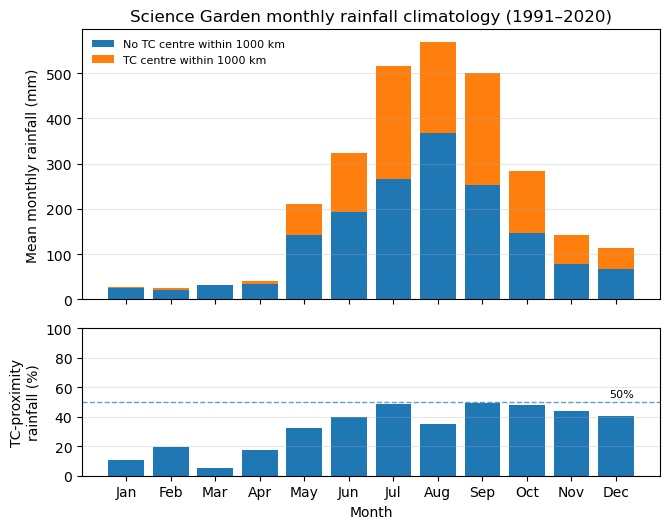

Saved: /home/jupyter-bbr/source/science-garden-rainfall-trends/output/figures/figure_01_climatology_tc_fraction.png


In [14]:
FIGURE_01_CLIMATOLOGY_ONLY_PATH = FIGURE_DIR / "figure_01_climatology_tc_fraction.png"

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(6.8, 5.4),
    sharex=True,
    gridspec_kw={"height_ratios": [2.2, 1.2]}
)

x = np.arange(len(monthly_climatology))

month_labels = monthly_climatology["month_label"]
nontc_vals = monthly_climatology["mean_nontc1000_rainfall_mm"]
tc_vals = monthly_climatology["mean_tc1000_rainfall_mm"]
fraction_vals = monthly_climatology["tc1000_fraction_percent"]

# -----------------------------
# Panel a: Stacked rainfall climatology
# -----------------------------
ax = axes[0]

ax.bar(
    x,
    nontc_vals,
    label="No TC centre within 1000 km"
)

ax.bar(
    x,
    tc_vals,
    bottom=nontc_vals,
    label="TC centre within 1000 km"
)

ax.set_ylabel("Mean monthly rainfall (mm)")
ax.set_title(f"Science Garden monthly rainfall climatology ({CLIM_START}–{CLIM_END})")
ax.grid(axis="y", alpha=0.3)
ax.legend(frameon=False, fontsize=8, loc="upper left")

# # Optional season labels
# ax.axvspan(-0.5, 3.5, alpha=0.1)
# ax.axvspan(9.5, 11.5, alpha=0.1)
# ax.axvspan(3.5, 9.5, alpha=0.04)

# ax.text(
#     1.5,
#     ax.get_ylim()[1] * 0.94,
#     DRY_SEASON_LABEL,
#     ha="center",
#     va="top",
#     fontsize=8
# )

# ax.text(
#     6.5,
#     ax.get_ylim()[1] * 0.94,
#     WET_SEASON_LABEL,
#     ha="center",
#     va="top",
#     fontsize=8
# )

# -----------------------------
# Panel b: TC-proximity rainfall fraction
# -----------------------------
ax = axes[1]

ax.bar(
    x,
    fraction_vals
)

ax.axhline(50, linewidth=1, linestyle="--", alpha=0.7)

ax.set_ylabel("TC-proximity\nrainfall (%)")
ax.set_xlabel("Month")
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.3)

ax.set_xticks(x)
ax.set_xticklabels(month_labels)

ax.text(
    11.4,
    52,
    "50%",
    ha="right",
    va="bottom",
    fontsize=8
)

plt.tight_layout()
plt.savefig(FIGURE_01_CLIMATOLOGY_ONLY_PATH, dpi=FIGURE_DPI, bbox_inches="tight")
plt.show()

print(f"Saved: {FIGURE_01_CLIMATOLOGY_ONLY_PATH}")

## Table 1. Principal rainfall index definitions

This section generates the manuscript table describing the principal rainfall indices used in the analysis.

The table is intentionally limited to the main indices discussed in the manuscript. The full set of calculated indices can be retained in the supplementary trend table.

In [15]:
TABLE_01_INDICES = [
    "PRCPTOT",
    "WD",
    "WD_RATE",
    "SDII",
    "R20mm",
    "R50mm",
    "RX1day",
    "RX5day",
    "CDD",
]

In [16]:
table_01_index_definitions = pd.DataFrame([
    {
        "index": index,
        "name": INDEX_METADATA[index]["name"],
        "definition": INDEX_METADATA[index]["definition"],
        "unit": INDEX_METADATA[index]["unit"],
        "interpretation": INDEX_METADATA[index]["interpretation"],
    }
    for index in TABLE_01_INDICES
])

display(table_01_index_definitions)

,index,name,definition,unit,interpretation
0,PRCPTOT,Wet-day rainfall total,"Total rainfall from wet days, where wet days a...",mm,Seasonal or annual rainfall accumulation from ...
1,WD,Wet days,Number of days with rainfall >= 1.0 mm.,days,Rainfall occurrence frequency.
2,WD_RATE,Wet-day fraction,Wet days divided by eligible valid days.,fraction,Fraction of valid days with rainfall >= 1.0 mm.
3,SDII,Simple daily intensity index,Wet-day rainfall total divided by number of we...,mm wet-day-1,Mean rainfall intensity on wet days.
4,R20mm,Heavy precipitation days,Number of days with rainfall >= 20 mm.,days,ETCCDI heavy precipitation day frequency.
5,R50mm,Days with rainfall >= 50 mm,Number of days with rainfall >= 50 mm.,days,Moderate-heavy rainfall frequency using a fixe...
6,RX1day,Maximum 1-day rainfall,Maximum daily rainfall within the period.,mm,Largest single-day rainfall total.
7,RX5day,Maximum 5-day rainfall,Maximum consecutive 5-day rainfall total withi...,mm,Largest multi-day rainfall accumulation.
8,CDD,Maximum consecutive dry days,Maximum number of consecutive days with rainfa...,days,Dry-spell persistence.


In [17]:
table_01_index_definitions.to_csv(TABLE_01_PATH, index=False)

print("Saved Table 1:")
print(f"- {TABLE_01_PATH}")

Saved Table 1:
- /home/jupyter-bbr/source/science-garden-rainfall-trends/output/tables/table_01_index_definitions.csv


## Annual and seasonal rainfall indices

This section calculates annual and seasonal rainfall indices for two rainfall subsets:

1. `all_days`: all valid rainfall observations;
2. `non_tc_1000km`: days without a TC centre within 1000 km.

The non-TC subset is created by masking TC-proximity days as missing. Therefore, for spell-based indices in the non-TC subset, TC-proximity days are excluded and break consecutive-day runs.

In [20]:
def get_run_lengths(flag_series):
    """
    Return lengths of consecutive True values.
    
    False and missing values break a run.
    """
    arr = pd.Series(flag_series).fillna(False).astype(bool).to_numpy()
    
    run_lengths = []
    current_length = 0
    
    for value in arr:
        if value:
            current_length += 1
        else:
            if current_length > 0:
                run_lengths.append(current_length)
            current_length = 0
    
    if current_length > 0:
        run_lengths.append(current_length)
    
    return run_lengths


def rx5day_calendar(rr):
    """
    Maximum consecutive 5-day rainfall total.
    
    Requires all five days in the rolling window to be valid.
    """
    rr = pd.Series(rr).astype(float)
    return rr.rolling(window=5, min_periods=5).sum().max()


def calculate_rainfall_indices_for_period(rr, wet_threshold=1.0):
    """
    Calculate rainfall indices for a single annual or seasonal period.
    
    rr should already represent the desired rainfall subset:
    - all valid days; or
    - non-TC days, with TC-proximity days masked as NaN.
    """
    rr = pd.Series(rr).astype(float)
    
    eligible_days = rr.notna().sum()
    
    if eligible_days == 0:
        return {
            "eligible_days": 0,
            "PRCPTOT": np.nan,
            "WD": np.nan,
            "WD_RATE": np.nan,
            "SDII": np.nan,
            "R20mm": np.nan,
            "R50mm": np.nan,
            "R100mm": np.nan,
            "RX1day": np.nan,
            "RX5day": np.nan,
            "DD": np.nan,
            "DD_RATE": np.nan,
            "CDD": np.nan,
            "CWD": np.nan,
            "MEAN_DRY_SPELL_LENGTH": np.nan,
            "TOTAL_DRY_SPELL_DAYS_GE7": np.nan,
        }
    
    wet = (rr >= wet_threshold) & rr.notna()
    dry = (rr < wet_threshold) & rr.notna()
    
    wet_lengths = get_run_lengths(wet)
    dry_lengths = get_run_lengths(dry)
    
    dry_lengths_ge7 = [x for x in dry_lengths if x >= 7]
    
    wd = int(wet.sum())
    dd = int(dry.sum())
    
    prcptot = rr.where(wet).sum()
    sdii = prcptot / wd if wd > 0 else np.nan
    
    return {
        "eligible_days": int(eligible_days),
        "PRCPTOT": prcptot,
        "WD": wd,
        "WD_RATE": wd / eligible_days,
        "SDII": sdii,
        "R20mm": int((rr >= 20).sum()),
        "R50mm": int((rr >= 50).sum()),
        "R100mm": int((rr >= 100).sum()),
        "RX1day": rr.max(),
        "RX5day": rx5day_calendar(rr),
        "DD": dd,
        "DD_RATE": dd / eligible_days,
        "CDD": max(dry_lengths) if len(dry_lengths) > 0 else 0,
        "CWD": max(wet_lengths) if len(wet_lengths) > 0 else 0,
        "MEAN_DRY_SPELL_LENGTH": np.mean(dry_lengths) if len(dry_lengths) > 0 else 0,
        "TOTAL_DRY_SPELL_DAYS_GE7": sum(dry_lengths_ge7) if len(dry_lengths_ge7) > 0 else 0,
    }

In [21]:
def calculate_annual_indices(data, rr_col, subset_name):
    """
    Calculate annual rainfall indices.
    
    Completeness screening uses original RAINFALL coverage, not the masked subset.
    """
    rows = []
    
    for year, g in data.groupby("YEAR"):
        g = g.sort_values("DATE").copy()
        
        rr = pd.to_numeric(g[rr_col], errors="coerce")
        rr_all = pd.to_numeric(g["RAINFALL"], errors="coerce")
        
        expected_days = expected_days_in_year(year)
        valid_days = rr_all.notna().sum()
        valid_fraction = valid_days / expected_days
        is_valid = valid_fraction >= MIN_VALID_FRACTION
        
        if is_valid:
            indices = calculate_rainfall_indices_for_period(
                rr,
                wet_threshold=WET_DAY_THRESHOLD
            )
        else:
            indices = {
                "eligible_days": rr.notna().sum(),
                "PRCPTOT": np.nan,
                "WD": np.nan,
                "WD_RATE": np.nan,
                "SDII": np.nan,
                "R20mm": np.nan,
                "R50mm": np.nan,
                "R100mm": np.nan,
                "RX1day": np.nan,
                "RX5day": np.nan,
                "DD": np.nan,
                "DD_RATE": np.nan,
                "CDD": np.nan,
                "CWD": np.nan,
                "MEAN_DRY_SPELL_LENGTH": np.nan,
                "TOTAL_DRY_SPELL_DAYS_GE7": np.nan,
            }
        
        rows.append({
            "period_type": "Annual",
            "period": "Annual",
            "subset": subset_name,
            "YEAR": year,
            "expected_days": expected_days,
            "valid_days": valid_days,
            "valid_fraction": valid_fraction,
            "is_valid": is_valid,
            **indices,
        })
    
    return pd.DataFrame(rows).sort_values(["subset", "YEAR"]).reset_index(drop=True)


annual_indices_all = calculate_annual_indices(
    data=analysis_df,
    rr_col="RAINFALL_all",
    subset_name="all_days"
)

annual_indices_non_tc = calculate_annual_indices(
    data=analysis_df,
    rr_col="RAINFALL_non_tc_1000km",
    subset_name="non_tc_1000km"
)

annual_indices = pd.concat(
    [annual_indices_all, annual_indices_non_tc],
    ignore_index=True
)

display(annual_indices.head())
display(annual_indices.tail())

,period_type,period,subset,YEAR,expected_days,valid_days,valid_fraction,is_valid,eligible_days,PRCPTOT,...,R50mm,R100mm,RX1day,RX5day,DD,DD_RATE,CDD,CWD,MEAN_DRY_SPELL_LENGTH,TOTAL_DRY_SPELL_DAYS_GE7
0,Annual,Annual,all_days,1961,365,361,0.989041,True,361,2593.2,...,12.0,4.0,128.3,394.4,223.0,0.617729,31.0,26.0,4.955556,143.0
1,Annual,Annual,all_days,1962,365,365,1.000000,True,365,2367.4,...,11.0,4.0,191.0,543.2,244.0,0.668493,40.0,10.0,5.422222,175.0
2,Annual,Annual,all_days,1963,365,365,1.000000,True,365,2257.2,...,12.0,1.0,114.3,247.5,225.0,0.616438,78.0,13.0,5.232558,141.0
3,Annual,Annual,all_days,1964,366,366,1.000000,True,366,2711.8,...,17.0,4.0,193.4,292.1,223.0,0.609290,42.0,18.0,3.982143,138.0
4,Annual,Annual,all_days,1965,365,365,1.000000,True,365,2140.6,...,8.0,2.0,159.8,263.5,238.0,0.652055,45.0,11.0,3.901639,132.0


,period_type,period,subset,YEAR,expected_days,valid_days,valid_fraction,is_valid,eligible_days,PRCPTOT,...,R50mm,R100mm,RX1day,RX5day,DD,DD_RATE,CDD,CWD,MEAN_DRY_SPELL_LENGTH,TOTAL_DRY_SPELL_DAYS_GE7
123,Annual,Annual,non_tc_1000km,2020,366,366,1.000000,True,290,1144.5,...,3.0,0.0,56.8,110.6,202.0,0.696552,45.0,4.0,3.884615,104.0
124,Annual,Annual,non_tc_1000km,2021,365,361,0.989041,True,308,1787.1,...,6.0,3.0,189.0,497.1,208.0,0.675325,16.0,15.0,4.333333,107.0
125,Annual,Annual,non_tc_1000km,2022,365,365,1.000000,True,312,1920.4,...,11.0,0.0,97.5,156.4,199.0,0.637821,22.0,8.0,3.262295,94.0
126,Annual,Annual,non_tc_1000km,2023,365,365,1.000000,True,322,2075.1,...,10.0,2.0,127.0,334.6,206.0,0.639752,21.0,8.0,4.291667,127.0
127,Annual,Annual,non_tc_1000km,2024,366,366,1.000000,True,299,1233.3,...,2.0,1.0,102.4,141.3,198.0,0.662207,32.0,10.0,4.500000,117.0


In [22]:
def calculate_seasonal_indices(data, rr_col, subset_name):
    """
    Calculate Nov-Apr and May-Oct rainfall indices.
    
    Completeness screening uses original RAINFALL coverage, not the masked subset.
    """
    rows = []
    
    for (season_year, season), g in data.groupby(["SEASON_YEAR", "SEASON"], observed=False):
        if pd.isna(season):
            continue
        
        g = g.sort_values("DATE").copy()
        
        rr = pd.to_numeric(g[rr_col], errors="coerce")
        rr_all = pd.to_numeric(g["RAINFALL"], errors="coerce")
        
        expected_days = expected_days_in_season(season_year, season)
        valid_days = rr_all.notna().sum()
        valid_fraction = valid_days / expected_days
        is_valid = valid_fraction >= MIN_VALID_FRACTION
        
        if is_valid:
            indices = calculate_rainfall_indices_for_period(
                rr,
                wet_threshold=WET_DAY_THRESHOLD
            )
        else:
            indices = {
                "eligible_days": rr.notna().sum(),
                "PRCPTOT": np.nan,
                "WD": np.nan,
                "WD_RATE": np.nan,
                "SDII": np.nan,
                "R20mm": np.nan,
                "R50mm": np.nan,
                "R100mm": np.nan,
                "RX1day": np.nan,
                "RX5day": np.nan,
                "DD": np.nan,
                "DD_RATE": np.nan,
                "CDD": np.nan,
                "CWD": np.nan,
                "MEAN_DRY_SPELL_LENGTH": np.nan,
                "TOTAL_DRY_SPELL_DAYS_GE7": np.nan,
            }
        
        rows.append({
            "period_type": "Seasonal",
            "period": season,
            "subset": subset_name,
            "YEAR": season_year,
            "SEASON_YEAR": season_year,
            "SEASON": season,
            "expected_days": expected_days,
            "valid_days": valid_days,
            "valid_fraction": valid_fraction,
            "is_valid": is_valid,
            **indices,
        })
    
    out = pd.DataFrame(rows)
    
    out["SEASON"] = pd.Categorical(
        out["SEASON"],
        categories=SEASON_ORDER,
        ordered=True
    )
    
    return (
        out
        .sort_values(["subset", "SEASON", "SEASON_YEAR"])
        .reset_index(drop=True)
    )


seasonal_indices_all = calculate_seasonal_indices(
    data=analysis_df,
    rr_col="RAINFALL_all",
    subset_name="all_days"
)

seasonal_indices_non_tc = calculate_seasonal_indices(
    data=analysis_df,
    rr_col="RAINFALL_non_tc_1000km",
    subset_name="non_tc_1000km"
)

seasonal_indices = pd.concat(
    [seasonal_indices_all, seasonal_indices_non_tc],
    ignore_index=True
)

display(seasonal_indices.head())
display(seasonal_indices.tail())

,period_type,period,subset,YEAR,SEASON_YEAR,SEASON,expected_days,valid_days,valid_fraction,is_valid,...,R50mm,R100mm,RX1day,RX5day,DD,DD_RATE,CDD,CWD,MEAN_DRY_SPELL_LENGTH,TOTAL_DRY_SPELL_DAYS_GE7
0,Seasonal,Nov-Apr,all_days,1961,1961,Nov-Apr,181,116,0.640884,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Seasonal,Nov-Apr,all_days,1962,1962,Nov-Apr,181,181,1.000000,True,...,1.0,0.0,51.6,97.1,157.0,0.867403,40.0,3.0,9.812500,137.0
2,Seasonal,Nov-Apr,all_days,1963,1963,Nov-Apr,181,181,1.000000,True,...,0.0,0.0,33.0,43.9,163.0,0.900552,78.0,5.0,20.375000,146.0
3,Seasonal,Nov-Apr,all_days,1964,1964,Nov-Apr,182,182,1.000000,True,...,0.0,0.0,44.6,73.4,154.0,0.846154,42.0,5.0,9.058824,126.0
4,Seasonal,Nov-Apr,all_days,1965,1965,Nov-Apr,181,181,1.000000,True,...,2.0,0.0,56.7,96.7,144.0,0.795580,45.0,7.0,7.578947,114.0


,period_type,period,subset,YEAR,SEASON_YEAR,SEASON,expected_days,valid_days,valid_fraction,is_valid,...,R50mm,R100mm,RX1day,RX5day,DD,DD_RATE,CDD,CWD,MEAN_DRY_SPELL_LENGTH,TOTAL_DRY_SPELL_DAYS_GE7
253,Seasonal,May-Oct,non_tc_1000km,2020,2020,May-Oct,184,184,1.0,True,...,3.0,0.0,56.8,110.6,63.0,0.508065,7.0,4.0,1.968750,7.0
254,Seasonal,May-Oct,non_tc_1000km,2021,2021,May-Oct,184,184,1.0,True,...,4.0,3.0,189.0,497.1,74.0,0.510345,12.0,15.0,3.363636,28.0
255,Seasonal,May-Oct,non_tc_1000km,2022,2022,May-Oct,184,184,1.0,True,...,10.0,0.0,97.5,156.4,64.0,0.447552,9.0,8.0,1.882353,9.0
256,Seasonal,May-Oct,non_tc_1000km,2023,2023,May-Oct,184,184,1.0,True,...,10.0,2.0,127.0,334.6,64.0,0.441379,8.0,8.0,2.133333,8.0
257,Seasonal,May-Oct,non_tc_1000km,2024,2024,May-Oct,184,184,1.0,True,...,2.0,1.0,102.4,141.3,60.0,0.441176,8.0,10.0,2.222222,8.0


In [23]:
ANNUAL_INDICES_PATH = TABLE_DIR / "annual_rainfall_indices.csv"
SEASONAL_INDICES_PATH = TABLE_DIR / "seasonal_rainfall_indices.csv"

annual_indices.to_csv(ANNUAL_INDICES_PATH, index=False)
seasonal_indices.to_csv(SEASONAL_INDICES_PATH, index=False)

print("Saved index tables:")
print(f"- {ANNUAL_INDICES_PATH}")
print(f"- {SEASONAL_INDICES_PATH}")## Trend analysis

This section estimates trends for the annual and seasonal rainfall indices.

Trend magnitude is estimated using ordinary least-squares regression and expressed per decade. The 95% confidence interval is calculated from the standard error of the OLS slope. Mann–Kendall and Theil–Sen estimates are used as non-parametric robustness checks.

Only valid annual or seasonal periods are used in trend estimation. Invalid periods have index values set to missing during the index-calculation step.

Saved index tables:
- /home/jupyter-bbr/source/science-garden-rainfall-trends/output/tables/annual_rainfall_indices.csv
- /home/jupyter-bbr/source/science-garden-rainfall-trends/output/tables/seasonal_rainfall_indices.csv


## Trend analysis

This section estimates trends for the annual and seasonal rainfall indices.

Trend magnitude is estimated using ordinary least-squares regression and expressed per decade. The 95% confidence interval is calculated from the standard error of the OLS slope. Mann–Kendall and Theil–Sen estimates are used as non-parametric robustness checks.

Only valid annual or seasonal periods are used in trend estimation. Invalid periods have index values set to missing during the index-calculation step.

In [24]:
def format_p_value(p):
    """
    Format p-values for display.
    """
    if pd.isna(p):
        return "NA"
    if p < 0.001:
        return "<0.001"
    return f"{p:.3f}"


def classify_trend(slope, p_value, alpha=0.05):
    """
    Classify trend direction based on slope and p-value.
    """
    if pd.isna(slope) or pd.isna(p_value):
        return "no_test"
    if p_value >= alpha:
        return "not_significant"
    if slope > 0:
        return "increasing"
    if slope < 0:
        return "decreasing"
    return "not_significant"


def mann_kendall_test(y, alpha=0.05):
    """
    Original two-sided Mann-Kendall trend test with tie correction.
    """
    y = pd.Series(y).dropna().to_numpy()
    n = len(y)
    
    if n < 3:
        return {
            "mk_s": np.nan,
            "mk_var_s": np.nan,
            "mk_z": np.nan,
            "mk_p_value": np.nan,
            "mk_tau": np.nan,
            "mk_trend": "no_test",
        }
    
    s = 0
    for k in range(n - 1):
        s += np.sign(y[k + 1:] - y[k]).sum()
    
    _, counts = np.unique(y, return_counts=True)
    tie_counts = counts[counts > 1]
    
    var_s = (
        n * (n - 1) * (2 * n + 5)
        - np.sum(tie_counts * (tie_counts - 1) * (2 * tie_counts + 5))
    ) / 18
    
    if var_s == 0:
        z = 0.0
        p_value = 1.0
    else:
        if s > 0:
            z = (s - 1) / np.sqrt(var_s)
        elif s < 0:
            z = (s + 1) / np.sqrt(var_s)
        else:
            z = 0.0
        
        p_value = 2 * (1 - norm.cdf(abs(z)))
    
    tau = s / (0.5 * n * (n - 1))
    
    if p_value < alpha and s > 0:
        trend = "increasing"
    elif p_value < alpha and s < 0:
        trend = "decreasing"
    else:
        trend = "not_significant"
    
    return {
        "mk_s": s,
        "mk_var_s": var_s,
        "mk_z": z,
        "mk_p_value": p_value,
        "mk_tau": tau,
        "mk_trend": trend,
    }


def theil_sen_slope(x, y):
    """
    Calculate Theil-Sen median pairwise slope.
    """
    clean = pd.DataFrame({"x": x, "y": y}).dropna().sort_values("x")
    
    if len(clean) < 3:
        return {
            "theil_sen_slope_per_year": np.nan,
            "theil_sen_slope_per_decade": np.nan,
        }
    
    x = clean["x"].to_numpy(dtype=float)
    y = clean["y"].to_numpy(dtype=float)
    
    slopes = []
    n = len(clean)
    
    for i in range(n - 1):
        dx = x[i + 1:] - x[i]
        dy = y[i + 1:] - y[i]
        valid = dx != 0
        
        if valid.any():
            slopes.extend((dy[valid] / dx[valid]).tolist())
    
    if len(slopes) == 0:
        slope = np.nan
    else:
        slope = np.median(slopes)
    
    return {
        "theil_sen_slope_per_year": slope,
        "theil_sen_slope_per_decade": slope * 10 if not pd.isna(slope) else np.nan,
    }


def ols_trend(x, y, alpha=0.05):
    """
    Calculate OLS trend and 95% confidence interval for the slope.
    """
    clean = pd.DataFrame({"x": x, "y": y}).dropna().sort_values("x")
    n = len(clean)
    
    if n < 3:
        return {
            "n_valid_periods": n,
            "year_start": np.nan,
            "year_end": np.nan,
            "ols_slope_per_year": np.nan,
            "ols_slope_per_decade": np.nan,
            "ols_ci_lower_per_decade": np.nan,
            "ols_ci_upper_per_decade": np.nan,
            "ols_intercept": np.nan,
            "ols_r_value": np.nan,
            "ols_p_value": np.nan,
            "ols_stderr_per_year": np.nan,
            "ols_trend": "no_test",
        }
    
    result = linregress(clean["x"], clean["y"])
    
    dof = n - 2
    t_crit = t.ppf(1 - alpha / 2, dof)
    
    ci_lower_per_year = result.slope - t_crit * result.stderr
    ci_upper_per_year = result.slope + t_crit * result.stderr
    
    return {
        "n_valid_periods": n,
        "year_start": int(clean["x"].min()),
        "year_end": int(clean["x"].max()),
        "ols_slope_per_year": result.slope,
        "ols_slope_per_decade": result.slope * 10,
        "ols_ci_lower_per_decade": ci_lower_per_year * 10,
        "ols_ci_upper_per_decade": ci_upper_per_year * 10,
        "ols_intercept": result.intercept,
        "ols_r_value": result.rvalue,
        "ols_p_value": result.pvalue,
        "ols_stderr_per_year": result.stderr,
        "ols_trend": classify_trend(result.slope, result.pvalue, alpha=alpha),
    }


def calculate_combined_trend(data, index_name, x_col="YEAR", alpha=0.05):
    """
    Calculate OLS, Mann-Kendall, and Theil-Sen trend diagnostics.
    """
    clean = data[[x_col, index_name]].dropna().sort_values(x_col).copy()
    
    ols = ols_trend(clean[x_col], clean[index_name], alpha=alpha)
    mk = mann_kendall_test(clean[index_name], alpha=alpha)
    ts = theil_sen_slope(clean[x_col], clean[index_name])
    
    return {
        **ols,
        **mk,
        **ts,
        "ols_p_label": format_p_value(ols["ols_p_value"]),
        "mk_p_label": format_p_value(mk["mk_p_value"]),
    }

In [25]:
all_period_indices = pd.concat(
    [
        annual_indices,
        seasonal_indices,
    ],
    ignore_index=True,
    sort=False
)

print("Combined annual and seasonal index table")
print("----------------------------------------")
print(f"Rows: {len(all_period_indices):,}")
print(f"Period types: {all_period_indices['period_type'].dropna().unique().tolist()}")
print(f"Periods: {all_period_indices['period'].dropna().unique().tolist()}")
print(f"Subsets: {all_period_indices['subset'].dropna().unique().tolist()}")

display(all_period_indices.head())

Combined annual and seasonal index table
----------------------------------------
Rows: 386
Period types: ['Annual', 'Seasonal']
Periods: ['Annual', 'Nov-Apr', 'May-Oct']
Subsets: ['all_days', 'non_tc_1000km']


,period_type,period,subset,YEAR,expected_days,valid_days,valid_fraction,is_valid,eligible_days,PRCPTOT,...,RX1day,RX5day,DD,DD_RATE,CDD,CWD,MEAN_DRY_SPELL_LENGTH,TOTAL_DRY_SPELL_DAYS_GE7,SEASON_YEAR,SEASON
0,Annual,Annual,all_days,1961,365,361,0.989041,True,361,2593.2,...,128.3,394.4,223.0,0.617729,31.0,26.0,4.955556,143.0,NaN,NaN
1,Annual,Annual,all_days,1962,365,365,1.000000,True,365,2367.4,...,191.0,543.2,244.0,0.668493,40.0,10.0,5.422222,175.0,NaN,NaN
2,Annual,Annual,all_days,1963,365,365,1.000000,True,365,2257.2,...,114.3,247.5,225.0,0.616438,78.0,13.0,5.232558,141.0,NaN,NaN
3,Annual,Annual,all_days,1964,366,366,1.000000,True,366,2711.8,...,193.4,292.1,223.0,0.609290,42.0,18.0,3.982143,138.0,NaN,NaN
4,Annual,Annual,all_days,1965,365,365,1.000000,True,365,2140.6,...,159.8,263.5,238.0,0.652055,45.0,11.0,3.901639,132.0,NaN,NaN


In [26]:
trend_rows = []

group_cols = ["period_type", "period", "subset"]

for (period_type, period, subset), g in all_period_indices.groupby(group_cols, observed=False):
    g = g.sort_values("YEAR").copy()
    
    for index_name in FULL_TREND_INDICES:
        if index_name not in g.columns:
            continue
        
        trend = calculate_combined_trend(
            data=g,
            index_name=index_name,
            x_col="YEAR",
            alpha=0.05
        )
        
        trend_rows.append({
            "period_type": period_type,
            "period": period,
            "subset": subset,
            "index": index_name,
            "index_name": INDEX_METADATA.get(index_name, {}).get("name", index_name),
            "unit": INDEX_METADATA.get(index_name, {}).get("unit", ""),
            **trend,
        })

full_trend_summary = pd.DataFrame(trend_rows)

# Add compact CI string for display
full_trend_summary["ols_slope_95ci_per_decade"] = full_trend_summary.apply(
    lambda row: (
        f"{row['ols_slope_per_decade']:.3f} "
        f"[{row['ols_ci_lower_per_decade']:.3f}, {row['ols_ci_upper_per_decade']:.3f}]"
        if pd.notna(row["ols_slope_per_decade"])
        else "NA"
    ),
    axis=1
)

display(full_trend_summary.head())

,period_type,period,subset,index,index_name,unit,n_valid_periods,year_start,year_end,ols_slope_per_year,...,mk_var_s,mk_z,mk_p_value,mk_tau,mk_trend,theil_sen_slope_per_year,theil_sen_slope_per_decade,ols_p_label,mk_p_label,ols_slope_95ci_per_decade
0,Annual,Annual,all_days,PRCPTOT,Wet-day rainfall total,mm,61,1961,2024,10.667682,...,25823.333333,2.794089,0.005205,0.245902,increasing,9.488596,94.885965,0.008,0.005,"106.677 [29.465, 183.889]"
1,Annual,Annual,all_days,WD,Wet days,days,61,1961,2024,0.352277,...,25771.333333,2.871656,0.004083,0.252459,increasing,0.307692,3.076923,0.002,0.004,"3.523 [1.396, 5.649]"
2,Annual,Annual,all_days,WD_RATE,Wet-day fraction,fraction,61,1961,2024,0.000933,...,25799.666667,2.801596,0.005085,0.246448,increasing,0.000786,0.007862,0.002,0.005,"0.009 [0.004, 0.015]"
3,Annual,Annual,all_days,SDII,Simple daily intensity index,mm wet-day-1,61,1961,2024,0.028494,...,25823.333333,1.586843,0.112548,0.139891,not_significant,0.030858,0.308580,0.171,0.113,"0.285 [-0.127, 0.697]"
4,Annual,Annual,all_days,R20mm,Heavy precipitation days,days,61,1961,2024,0.191166,...,25729.000000,3.603432,0.000314,0.316393,increasing,0.190476,1.904762,<0.001,<0.001,"1.912 [0.934, 2.889]"


In [27]:
headline_indices = sorted(
    set(FIGURE_02_INDICES + FIGURE_03_INDICES + FIGURE_04_INDICES)
)

headline_trends = full_trend_summary[
    full_trend_summary["index"].isin(headline_indices)
].copy()

display(
    headline_trends[
        [
            "period_type",
            "period",
            "subset",
            "index",
            "n_valid_periods",
            "year_start",
            "year_end",
            "ols_slope_95ci_per_decade",
            "ols_p_label",
            "mk_p_label",
            "theil_sen_slope_per_decade",
            "ols_trend",
            "mk_trend",
        ]
    ]
    .sort_values(["period_type", "period", "subset", "index"])
)

,period_type,period,subset,index,n_valid_periods,year_start,year_end,ols_slope_95ci_per_decade,ols_p_label,mk_p_label,theil_sen_slope_per_decade,ols_trend,mk_trend
10,Annual,Annual,all_days,CDD,61,1961,2024,"-4.853 [-7.643, -2.063]",<0.001,0.001,-3.333333,decreasing,decreasing
0,Annual,Annual,all_days,PRCPTOT,61,1961,2024,"106.677 [29.465, 183.889]",0.008,0.005,94.885965,increasing,increasing
4,Annual,Annual,all_days,R20mm,61,1961,2024,"1.912 [0.934, 2.889]",<0.001,<0.001,1.904762,increasing,increasing
5,Annual,Annual,all_days,R50mm,61,1961,2024,"0.927 [0.252, 1.603]",0.008,0.009,0.919662,increasing,increasing
7,Annual,Annual,all_days,RX1day,61,1961,2024,"6.611 [-3.326, 16.548]",0.188,0.394,3.112159,not_significant,not_significant
1,Annual,Annual,all_days,WD,61,1961,2024,"3.523 [1.396, 5.649]",0.002,0.004,3.076923,increasing,increasing
2,Annual,Annual,all_days,WD_RATE,61,1961,2024,"0.009 [0.004, 0.015]",0.002,0.005,0.007862,increasing,increasing
23,Annual,Annual,non_tc_1000km,CDD,61,1961,2024,"-5.078 [-7.709, -2.447]",<0.001,<0.001,-3.636364,decreasing,decreasing
13,Annual,Annual,non_tc_1000km,PRCPTOT,61,1961,2024,"125.861 [71.175, 180.546]",<0.001,<0.001,134.253724,increasing,increasing
17,Annual,Annual,non_tc_1000km,R20mm,61,1961,2024,"2.459 [1.771, 3.147]",<0.001,<0.001,2.692308,increasing,increasing


In [28]:
table_02_selection = pd.DataFrame([
    # Annual
    {"period_type": "Annual", "period": "Annual", "index": "PRCPTOT"},
    {"period_type": "Annual", "period": "Annual", "index": "WD"},
    {"period_type": "Annual", "period": "Annual", "index": "R20mm"},
    {"period_type": "Annual", "period": "Annual", "index": "R50mm"},
    {"period_type": "Annual", "period": "Annual", "index": "RX1day"},
    
    # Nov-Apr
    {"period_type": "Seasonal", "period": DRY_SEASON_LABEL, "index": "PRCPTOT"},
    {"period_type": "Seasonal", "period": DRY_SEASON_LABEL, "index": "WD_RATE"},
    {"period_type": "Seasonal", "period": DRY_SEASON_LABEL, "index": "R20mm"},
    {"period_type": "Seasonal", "period": DRY_SEASON_LABEL, "index": "CDD"},
    {"period_type": "Seasonal", "period": DRY_SEASON_LABEL, "index": "RX1day"},
    
    # May-Oct
    {"period_type": "Seasonal", "period": WET_SEASON_LABEL, "index": "PRCPTOT"},
    {"period_type": "Seasonal", "period": WET_SEASON_LABEL, "index": "WD_RATE"},
    {"period_type": "Seasonal", "period": WET_SEASON_LABEL, "index": "R20mm"},
    {"period_type": "Seasonal", "period": WET_SEASON_LABEL, "index": "R50mm"},
    {"period_type": "Seasonal", "period": WET_SEASON_LABEL, "index": "RX1day"},
])

table_02_selected_trends = full_trend_summary.merge(
    table_02_selection,
    on=["period_type", "period", "index"],
    how="inner"
)

# Sort table in intended order
table_02_selected_trends["period_order"] = table_02_selected_trends["period"].map({
    "Annual": 0,
    DRY_SEASON_LABEL: 1,
    WET_SEASON_LABEL: 2,
})

table_02_selected_trends["subset_order"] = table_02_selected_trends["subset"].map({
    "all_days": 0,
    "non_tc_1000km": 1,
})

table_02_selected_trends["index_order"] = table_02_selected_trends["index"].map({
    "PRCPTOT": 0,
    "WD": 1,
    "WD_RATE": 2,
    "R20mm": 3,
    "R50mm": 4,
    "CDD": 5,
    "RX1day": 6,
})

table_02_selected_trends = (
    table_02_selected_trends
    .sort_values(["period_order", "subset_order", "index_order"])
    .reset_index(drop=True)
)

table_02_display_cols = [
    "period_type",
    "period",
    "subset",
    "index",
    "index_name",
    "unit",
    "n_valid_periods",
    "year_start",
    "year_end",
    "ols_slope_per_decade",
    "ols_ci_lower_per_decade",
    "ols_ci_upper_per_decade",
    "ols_p_value",
    "mk_p_value",
    "theil_sen_slope_per_decade",
    "ols_trend",
    "mk_trend",
]

table_02_selected_trends = table_02_selected_trends[table_02_display_cols]

display(table_02_selected_trends)

,period_type,period,subset,index,index_name,unit,n_valid_periods,year_start,year_end,ols_slope_per_decade,ols_ci_lower_per_decade,ols_ci_upper_per_decade,ols_p_value,mk_p_value,theil_sen_slope_per_decade,ols_trend,mk_trend
0,Annual,Annual,all_days,PRCPTOT,Wet-day rainfall total,mm,61,1961,2024,106.676817,29.464786,183.888848,7.593633e-03,5.204620e-03,94.885965,increasing,increasing
1,Annual,Annual,all_days,WD,Wet days,days,61,1961,2024,3.522772,1.396262,5.649282,1.571579e-03,4.083266e-03,3.076923,increasing,increasing
2,Annual,Annual,all_days,R20mm,Heavy precipitation days,days,61,1961,2024,1.911662,0.934068,2.889256,2.385951e-04,3.140424e-04,1.904762,increasing,increasing
3,Annual,Annual,all_days,R50mm,Days with rainfall >= 50 mm,days,61,1961,2024,0.927341,0.252161,1.602522,7.935284e-03,8.743796e-03,0.919662,increasing,increasing
4,Annual,Annual,all_days,RX1day,Maximum 1-day rainfall,mm,61,1961,2024,6.610656,-3.326352,16.547663,1.882527e-01,3.939148e-01,3.112159,not_significant,not_significant
5,Annual,Annual,non_tc_1000km,PRCPTOT,Wet-day rainfall total,mm,61,1961,2024,125.860600,71.175018,180.546183,2.244092e-05,6.622850e-07,134.253724,increasing,increasing
6,Annual,Annual,non_tc_1000km,WD,Wet days,days,61,1961,2024,6.372630,4.592136,8.153124,1.439379e-09,8.813491e-08,6.388889,increasing,increasing
7,Annual,Annual,non_tc_1000km,R20mm,Heavy precipitation days,days,61,1961,2024,2.458819,1.770627,3.147011,1.511550e-09,4.005851e-09,2.692308,increasing,increasing
8,Annual,Annual,non_tc_1000km,R50mm,Days with rainfall >= 50 mm,days,61,1961,2024,0.611369,0.186634,1.036103,5.530177e-03,1.052458e-03,0.714286,increasing,increasing
9,Annual,Annual,non_tc_1000km,RX1day,Maximum 1-day rainfall,mm,61,1961,2024,0.566718,-8.819329,9.952766,9.042459e-01,8.763650e-01,0.457516,not_significant,not_significant


In [36]:
full_trend_summary.to_csv(SUPP_TABLE_S1_PATH, index=False)
table_02_selected_trends.to_csv(TABLE_02_PATH, index=False)

print("Saved trend tables:")
print(f"- {TABLE_02_PATH}")
print(f"- {SUPP_TABLE_S1_PATH}")## Manuscript time-series figures


Saved trend tables:
- /home/jupyter-bbr/source/science-garden-rainfall-trends/output/tables/table_02_selected_trends.csv
- /home/jupyter-bbr/source/science-garden-rainfall-trends/output/tables/supplementary/supplementary_table_s1_full_trends.csv


## Manuscript time-series figures

This section generates compact multi-panel time-series figures for selected annual and seasonal rainfall indices.

Each panel shows:

- annual or seasonal index values;
- all-days and TC-proximity-filtered series;
- OLS trend lines fitted to unsmoothed values;
- optional 10-year running means for visual guidance.

Trend statistics are calculated from unsmoothed annual or seasonal index series.

In [ ]:
DIAGNOSTIC_FIGURE_DIR = FIGURE_DIR / "diagnostic_timeseries"
DIAGNOSTIC_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

In [41]:
def subset_label(subset):
    labels = {
        "all_days": "All days",
        "non_tc_1000km": "No TC centre within 1000 km",
    }
    return labels.get(subset, subset)


def subset_short_label(subset):
    labels = {
        "all_days": "All",
        "non_tc_1000km": "Non-TC",
    }
    return labels.get(subset, subset)


def index_axis_label(index_name):
    meta = INDEX_METADATA.get(index_name, {})
    name = meta.get("name", index_name)
    unit = meta.get("unit", "")
    
    if unit == "fraction":
        return name
    elif unit:
        return f"{name} ({unit})"
    else:
        return name


def format_stat_p(p):
    if pd.isna(p):
        return "p = NA"
    if p < 0.001:
        return "p < 0.001"
    return f"p = {p:.3f}"


def format_slope_for_index(slope_per_decade, index_name):
    """
    Format OLS slope per decade for annotation.
    Fraction indices are converted to percentage points per decade.
    """
    if pd.isna(slope_per_decade):
        return "NA"
    
    unit = INDEX_METADATA.get(index_name, {}).get("unit", "")
    
    if unit == "fraction":
        return f"{slope_per_decade * 100:+.2f} pp decade$^{{-1}}$"
    
    if abs(slope_per_decade) >= 100:
        return f"{slope_per_decade:+.1f} decade$^{{-1}}$"
    elif abs(slope_per_decade) >= 10:
        return f"{slope_per_decade:+.2f} decade$^{{-1}}$"
    else:
        return f"{slope_per_decade:+.3f} decade$^{{-1}}$"


def get_compact_trend_annotation(
    trend_summary,
    period_type,
    period,
    index_name,
    subset,
):
    row = trend_summary[
        (trend_summary["period_type"] == period_type)
        & (trend_summary["period"] == period)
        & (trend_summary["subset"] == subset)
        & (trend_summary["index"] == index_name)
    ]
    
    if len(row) == 0:
        return None
    
    row = row.iloc[0]
    
    slope_text = format_slope_for_index(row["ols_slope_per_decade"], index_name)
    p_text = format_stat_p(row["ols_p_value"])
    
    if pd.isna(row["ols_r_value"]):
        r_text = "r = NA"
    else:
        r_text = f"r = {row['ols_r_value']:.2f}"
    
    return f"{subset_short_label(subset)}: {slope_text}; {r_text}; {p_text}"


def slugify_text(text):
    return (
        str(text)
        .lower()
        .replace(" ", "_")
        .replace("–", "-")
        .replace("—", "-")
        .replace("/", "_")
        .replace("\\", "_")
        .replace("(", "")
        .replace(")", "")
    )

In [42]:
def plot_single_index_timeseries(
    data,
    trend_summary,
    index_name,
    period_type,
    period,
    output_path=None,
    subsets=("all_days", "non_tc_1000km"),
    show_running_mean=True,
    rolling_window=10,
    annotate_stats=True,
    figsize=(7.2, 4.0),
):
    """
    Plot one annual or seasonal rainfall index as a standalone diagnostic figure.

    Layout:
    - centered title;
    - compact trend statistics below title;
    - legend inside the plot, upper left;
    - x-axis limited to actual valid data range.
    """
    fig, ax = plt.subplots(figsize=figsize)

    annotation_lines = []
    all_valid_years = []

    for subset in subsets:
        g = data[
            (data["period_type"] == period_type)
            & (data["period"] == period)
            & (data["subset"] == subset)
        ].sort_values("YEAR").copy()

        if g.empty or index_name not in g.columns:
            continue

        valid_g = g[g[index_name].notna()].copy()
        if valid_g.empty:
            continue

        all_valid_years.extend(valid_g["YEAR"].tolist())

        # Raw values
        line = ax.plot(
            valid_g["YEAR"],
            valid_g[index_name],
            marker="o",
            markersize=3.0,
            linewidth=0.8,
            alpha=0.45,
            label=subset_label(subset),
        )[0]

        line_color = line.get_color()

        # Optional running mean
        if show_running_mean:
            running_col = f"{index_name}_running"
            valid_g[running_col] = (
                valid_g[index_name]
                .rolling(
                    window=rolling_window,
                    min_periods=max(3, rolling_window // 2),
                )
                .mean()
            )

            ax.plot(
                valid_g["YEAR"],
                valid_g[running_col],
                linewidth=1.7,
                alpha=0.85,
                color=line_color,
                linestyle="-",
            )

        # OLS trend line
        trend_row = trend_summary[
            (trend_summary["period_type"] == period_type)
            & (trend_summary["period"] == period)
            & (trend_summary["subset"] == subset)
            & (trend_summary["index"] == index_name)
        ]

        if len(trend_row) > 0:
            trend_row = trend_row.iloc[0]

            if pd.notna(trend_row["ols_slope_per_year"]) and pd.notna(trend_row["ols_intercept"]):
                x_trend = np.array([
                    valid_g["YEAR"].min(),
                    valid_g["YEAR"].max(),
                ])

                y_trend = (
                    trend_row["ols_intercept"]
                    + trend_row["ols_slope_per_year"] * x_trend
                )

                ax.plot(
                    x_trend,
                    y_trend,
                    linewidth=1.4,
                    linestyle="--",
                    color=line_color,
                    alpha=0.95,
                )

        # Trend annotation
        if annotate_stats:
            annotation = get_compact_trend_annotation(
                trend_summary=trend_summary,
                period_type=period_type,
                period=period,
                index_name=index_name,
                subset=subset,
            )

            if annotation is not None:
                annotation_lines.append(annotation)

    # -----------------------------
    # Titles and labels
    # -----------------------------
    period_label = period if period_type != "Annual" else "Annual"

    ax.set_title(
        f"{period_label}: {index_name}",
        fontsize=11,
        loc="center",
        pad=34,
    )

    if annotate_stats and len(annotation_lines) > 0:
        ax.text(
            0.5,
            1.03,
            "\n".join(annotation_lines),
            transform=ax.transAxes,
            ha="center",
            va="bottom",
            fontsize=8,
        )

    ax.set_ylabel(index_axis_label(index_name), fontsize=9)
    ax.set_xlabel("Year", fontsize=9)

    # -----------------------------
    # X-axis: limit to actual data range, no forced 2030
    # -----------------------------
    # if len(all_valid_years) > 0:
    #     year_min = int(np.min(all_valid_years))
    #     year_max = int(np.max(all_valid_years))

    #     ax.set_xlim(year_min - 1, year_max + 1)

    #     # Decadal ticks only within data range
    #     first_tick = int(np.ceil(year_min / 10) * 10)
    #     last_tick = int(np.floor(year_max / 10) * 10)
    #     ticks = list(np.arange(first_tick, last_tick + 1, 10))

    #     # Optionally include first and last year if useful
    #     if year_min not in ticks:
    #         ticks = [year_min] + ticks
    #     if year_max not in ticks:
    #         ticks = ticks + [year_max]

    #     ax.set_xticks(ticks)
    # -----------------------------
    # X-axis: limit to actual data range, but use clean decadal ticks
    # -----------------------------
    if len(all_valid_years) > 0:
        year_min = int(np.min(all_valid_years))
        year_max = int(np.max(all_valid_years))

        ax.set_xlim(year_min - 0.5, year_max + 0.5)

        # Clean decade ticks only
        first_tick = int(np.ceil(year_min / 10) * 10)
        last_tick = int(np.floor(year_max / 10) * 10)

        decade_ticks = np.arange(first_tick, last_tick + 1, 10)

        ax.set_xticks(decade_ticks)

    # -----------------------------
    # Legend and styling
    # -----------------------------
    ax.legend(
        frameon=True,
        fontsize=8,
        loc="upper left",
        ncol=1,
    )

    ax.grid(True, alpha=0.25)
    ax.tick_params(axis="both", labelsize=8)

    fig.tight_layout()

    if output_path is not None:
        plt.savefig(output_path, dpi=FIGURE_DPI, bbox_inches="tight")
        print(f"Saved: {output_path}")

    plt.show()

Saved: /home/jupyter-bbr/source/science-garden-rainfall-trends/output/figures/diagnostic_timeseries/annual_prcptot.png


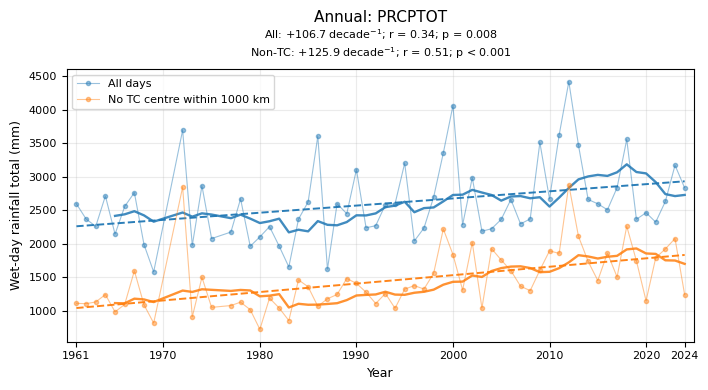

In [43]:
plot_single_index_timeseries(
    data=all_period_indices,
    trend_summary=full_trend_summary,
    index_name="PRCPTOT",
    period_type="Annual",
    period="Annual",
    output_path=DIAGNOSTIC_FIGURE_DIR / "annual_prcptot.png",
    show_running_mean=SHOW_RUNNING_MEAN,
    rolling_window=ROLLING_WINDOW,
    annotate_stats=True,
    figsize=(7.2, 4.0),
)

Saved: /home/jupyter-bbr/source/science-garden-rainfall-trends/output/figures/diagnostic_timeseries/annual_wd.png


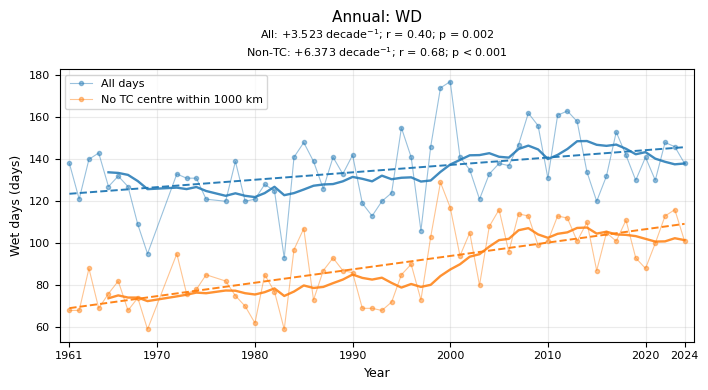

In [44]:
plot_single_index_timeseries(
    data=all_period_indices,
    trend_summary=full_trend_summary,
    index_name="WD",
    period_type="Annual",
    period="Annual",
    output_path=DIAGNOSTIC_FIGURE_DIR / "annual_wd.png",
    show_running_mean=SHOW_RUNNING_MEAN,
    rolling_window=ROLLING_WINDOW,
    annotate_stats=True,
    figsize=(7.2, 4.0),
)

Saved: /home/jupyter-bbr/source/science-garden-rainfall-trends/output/figures/diagnostic_timeseries/annual_wd.png


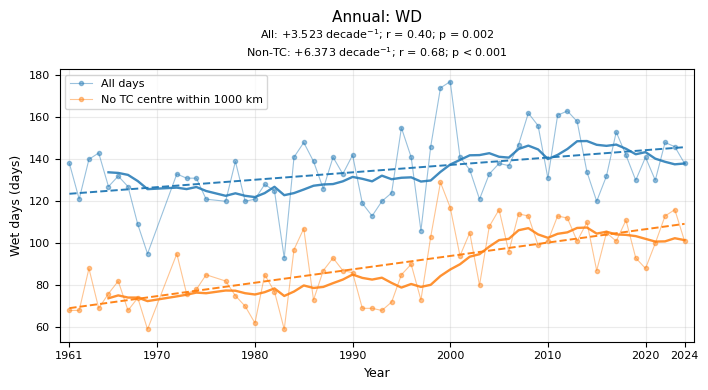

In [45]:
plot_single_index_timeseries(
    data=all_period_indices,
    trend_summary=full_trend_summary,
    index_name="WD",
    period_type="Annual",
    period="Annual",
    output_path=DIAGNOSTIC_FIGURE_DIR / "annual_wd.png",
    show_running_mean=SHOW_RUNNING_MEAN,
    rolling_window=ROLLING_WINDOW,
    annotate_stats=True,
    figsize=(7.2, 4.0),
)

Saved: /home/jupyter-bbr/source/science-garden-rainfall-trends/output/figures/diagnostic_timeseries/annual_r20mm.png


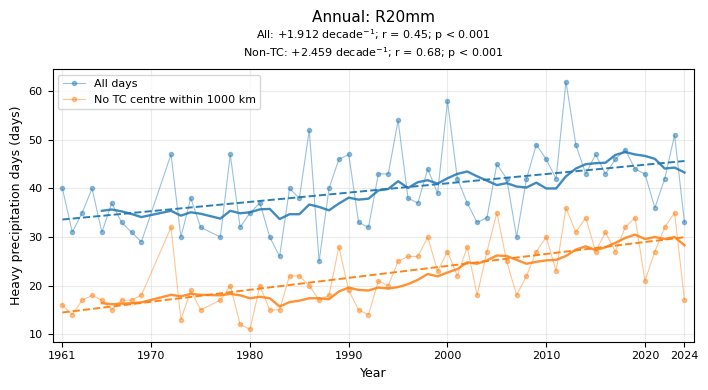

In [46]:
plot_single_index_timeseries(
    data=all_period_indices,
    trend_summary=full_trend_summary,
    index_name="R20mm",
    period_type="Annual",
    period="Annual",
    output_path=DIAGNOSTIC_FIGURE_DIR / "annual_r20mm.png",
    show_running_mean=SHOW_RUNNING_MEAN,
    rolling_window=ROLLING_WINDOW,
    annotate_stats=True,
    figsize=(7.2, 4.0),
)

Saved: /home/jupyter-bbr/source/science-garden-rainfall-trends/output/figures/diagnostic_timeseries/annual_r50mm.png


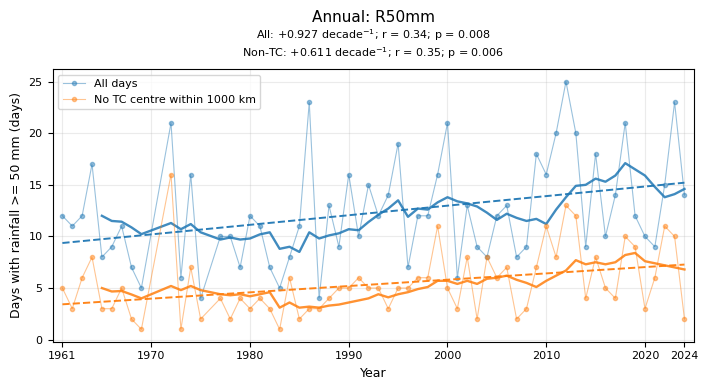

In [47]:
plot_single_index_timeseries(
    data=all_period_indices,
    trend_summary=full_trend_summary,
    index_name="R50mm",
    period_type="Annual",
    period="Annual",
    output_path=DIAGNOSTIC_FIGURE_DIR / "annual_r50mm.png",
    show_running_mean=SHOW_RUNNING_MEAN,
    rolling_window=ROLLING_WINDOW,
    annotate_stats=True,
    figsize=(7.2, 4.0),
)

Saved: /home/jupyter-bbr/source/science-garden-rainfall-trends/output/figures/diagnostic_timeseries/annual_rx1day.png


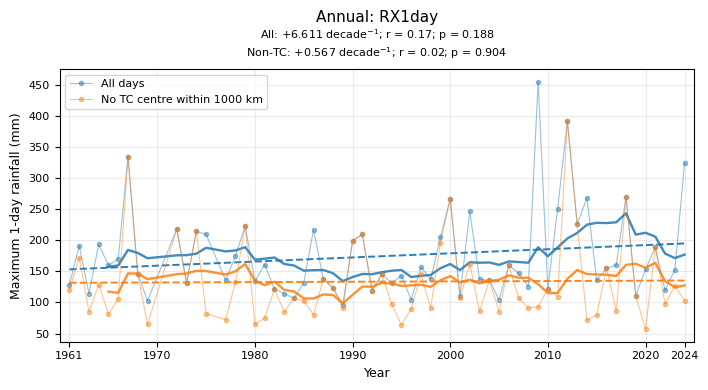

In [48]:
plot_single_index_timeseries(
    data=all_period_indices,
    trend_summary=full_trend_summary,
    index_name="RX1day",
    period_type="Annual",
    period="Annual",
    output_path=DIAGNOSTIC_FIGURE_DIR / "annual_rx1day.png",
    show_running_mean=SHOW_RUNNING_MEAN,
    rolling_window=ROLLING_WINDOW,
    annotate_stats=True,
    figsize=(7.2, 4.0),
)

## Individual May–October rainfall-index plots

This section generates individual diagnostic plots for the May–October season. These plots are intended for inspection and manuscript figure selection.

Each plot shows:

- all-days series;
- TC-proximity-filtered series;
- optional 10-year running mean;
- OLS trend line;
- OLS slope, r-value, and p-value.

In [51]:
print("Wet-season label:", WET_SEASON_LABEL)

display(
    all_period_indices[
        (all_period_indices["period_type"] == "Seasonal")
        & (all_period_indices["period"] == WET_SEASON_LABEL)
    ][["period", "subset", "YEAR", "PRCPTOT", "WD_RATE", "R20mm", "R50mm", "RX1day"]]
    .head()
)

Wet-season label: May-Oct


,period,subset,YEAR,PRCPTOT,WD_RATE,R20mm,R50mm,RX1day
193,May-Oct,all_days,1961,2363.8,0.619565,36.0,11.0,128.3
194,May-Oct,all_days,1962,2143.7,0.516304,28.0,11.0,191.0
195,May-Oct,all_days,1963,2104.3,0.641304,34.0,12.0,114.3
196,May-Oct,all_days,1964,2273.3,0.565217,36.0,15.0,193.4
197,May-Oct,all_days,1965,1915.3,0.532609,29.0,8.0,159.8


Saved: /home/jupyter-bbr/source/science-garden-rainfall-trends/output/figures/diagnostic_timeseries/may_oct_prcptot.png


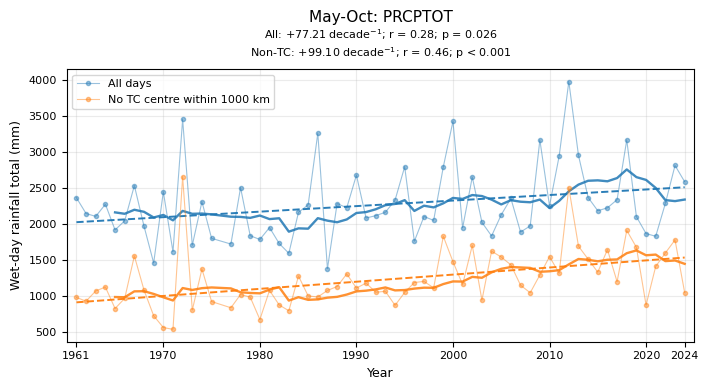

In [52]:
plot_single_index_timeseries(
    data=all_period_indices,
    trend_summary=full_trend_summary,
    index_name="PRCPTOT",
    period_type="Seasonal",
    period=WET_SEASON_LABEL,
    output_path=DIAGNOSTIC_FIGURE_DIR / "may_oct_prcptot.png",
    show_running_mean=SHOW_RUNNING_MEAN,
    rolling_window=ROLLING_WINDOW,
    annotate_stats=True,
    figsize=(7.2, 4.0),
)

Saved: /home/jupyter-bbr/source/science-garden-rainfall-trends/output/figures/diagnostic_timeseries/may_oct_wd_rate.png


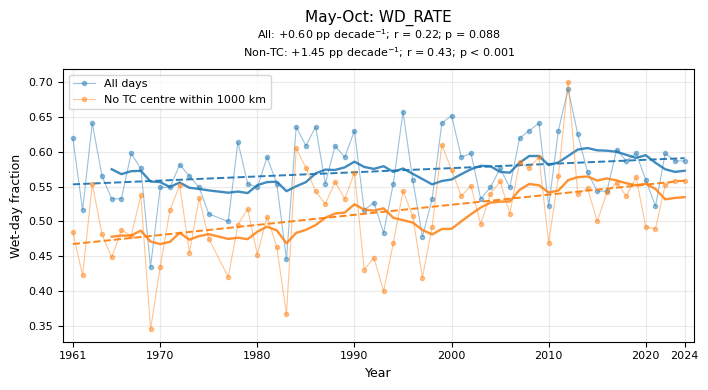

In [53]:
plot_single_index_timeseries(
    data=all_period_indices,
    trend_summary=full_trend_summary,
    index_name="WD_RATE",
    period_type="Seasonal",
    period=WET_SEASON_LABEL,
    output_path=DIAGNOSTIC_FIGURE_DIR / "may_oct_wd_rate.png",
    show_running_mean=SHOW_RUNNING_MEAN,
    rolling_window=ROLLING_WINDOW,
    annotate_stats=True,
    figsize=(7.2, 4.0),
)

Saved: /home/jupyter-bbr/source/science-garden-rainfall-trends/output/figures/diagnostic_timeseries/may_oct_r20mm.png


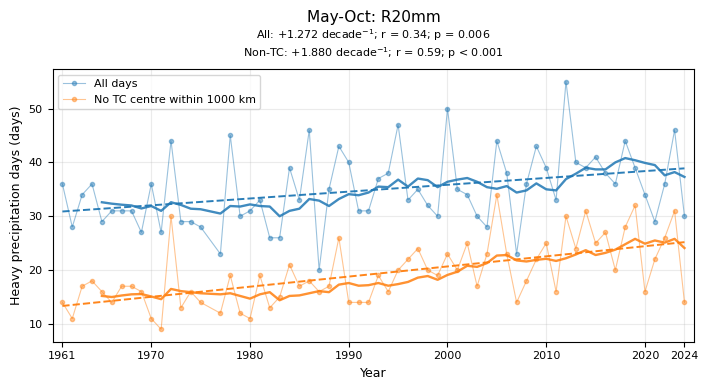

In [54]:
plot_single_index_timeseries(
    data=all_period_indices,
    trend_summary=full_trend_summary,
    index_name="R20mm",
    period_type="Seasonal",
    period=WET_SEASON_LABEL,
    output_path=DIAGNOSTIC_FIGURE_DIR / "may_oct_r20mm.png",
    show_running_mean=SHOW_RUNNING_MEAN,
    rolling_window=ROLLING_WINDOW,
    annotate_stats=True,
    figsize=(7.2, 4.0),
)

Saved: /home/jupyter-bbr/source/science-garden-rainfall-trends/output/figures/diagnostic_timeseries/may_oct_r50mm.png


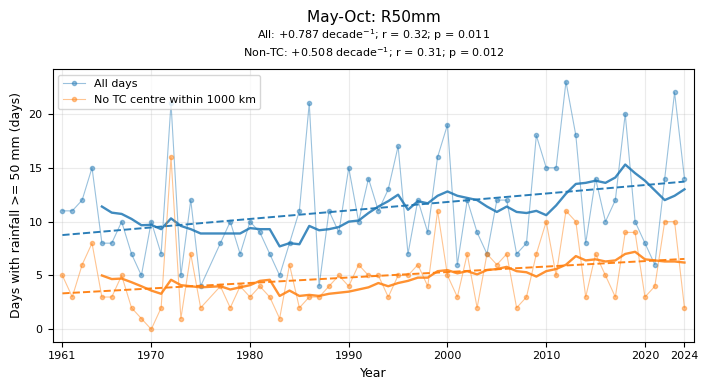

In [55]:
plot_single_index_timeseries(
    data=all_period_indices,
    trend_summary=full_trend_summary,
    index_name="R50mm",
    period_type="Seasonal",
    period=WET_SEASON_LABEL,
    output_path=DIAGNOSTIC_FIGURE_DIR / "may_oct_r50mm.png",
    show_running_mean=SHOW_RUNNING_MEAN,
    rolling_window=ROLLING_WINDOW,
    annotate_stats=True,
    figsize=(7.2, 4.0),
)

Saved: /home/jupyter-bbr/source/science-garden-rainfall-trends/output/figures/diagnostic_timeseries/may_oct_rx1day.png


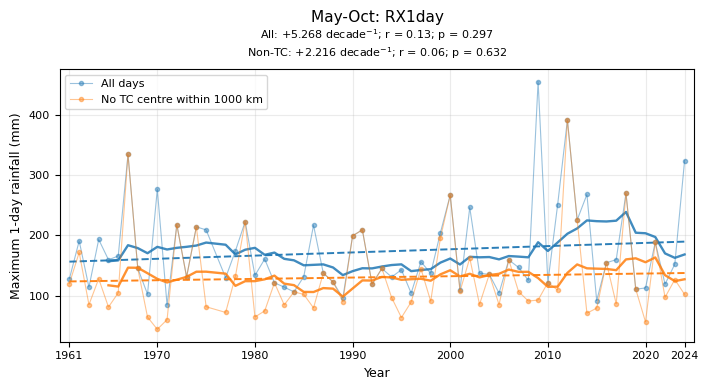

In [56]:
plot_single_index_timeseries(
    data=all_period_indices,
    trend_summary=full_trend_summary,
    index_name="RX1day",
    period_type="Seasonal",
    period=WET_SEASON_LABEL,
    output_path=DIAGNOSTIC_FIGURE_DIR / "may_oct_rx1day.png",
    show_running_mean=SHOW_RUNNING_MEAN,
    rolling_window=ROLLING_WINDOW,
    annotate_stats=True,
    figsize=(7.2, 4.0),
)

Saved: /home/jupyter-bbr/source/science-garden-rainfall-trends/output/figures/diagnostic_timeseries/may_oct_cdd.png


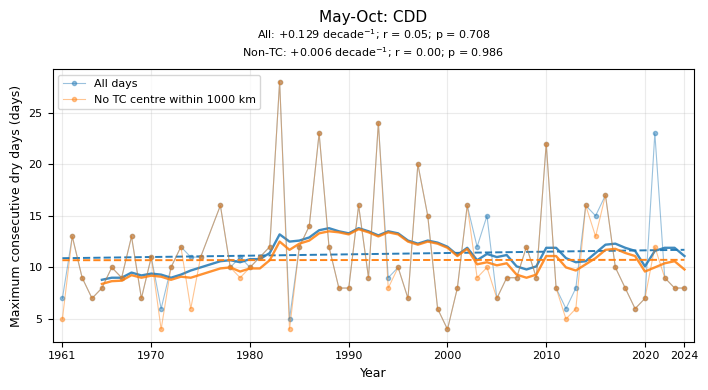

In [64]:
plot_single_index_timeseries(
    data=all_period_indices,
    trend_summary=full_trend_summary,
    index_name="CDD",
    period_type="Seasonal",
    period=WET_SEASON_LABEL,
    output_path=DIAGNOSTIC_FIGURE_DIR / "may_oct_cdd.png",
    show_running_mean=SHOW_RUNNING_MEAN,
    rolling_window=ROLLING_WINDOW,
    annotate_stats=True,
    figsize=(7.2, 4.0),
)

## Individual November–April rainfall-index plots

This section generates individual diagnostic plots for the November–April season. These plots are intended for inspection and manuscript figure selection.

The principal dry-season plots are:

- PRCPTOT;
- WD_RATE;
- R20mm;
- CDD.

Optional dry-spell diagnostic plots are also included for mean dry-spell length and total days within dry spells lasting at least 7 days.

In [57]:
print("Dry-season label:", DRY_SEASON_LABEL)

display(
    all_period_indices[
        (all_period_indices["period_type"] == "Seasonal")
        & (all_period_indices["period"] == DRY_SEASON_LABEL)
    ][
        [
            "period",
            "subset",
            "YEAR",
            "PRCPTOT",
            "WD_RATE",
            "R20mm",
            "CDD",
            "MEAN_DRY_SPELL_LENGTH",
            "TOTAL_DRY_SPELL_DAYS_GE7",
        ]
    ]
    .head()
)

Dry-season label: Nov-Apr


,period,subset,YEAR,PRCPTOT,WD_RATE,R20mm,CDD,MEAN_DRY_SPELL_LENGTH,TOTAL_DRY_SPELL_DAYS_GE7
128,Nov-Apr,all_days,1961,NaN,NaN,NaN,NaN,NaN,NaN
129,Nov-Apr,all_days,1962,241.9,0.132597,4.0,40.0,9.812500,137.0
130,Nov-Apr,all_days,1963,110.7,0.099448,1.0,78.0,20.375000,146.0
131,Nov-Apr,all_days,1964,212.4,0.153846,1.0,42.0,9.058824,126.0
132,Nov-Apr,all_days,1965,417.9,0.204420,4.0,45.0,7.578947,114.0


Saved: /home/jupyter-bbr/source/science-garden-rainfall-trends/output/figures/diagnostic_timeseries/nov_apr_prcptot.png


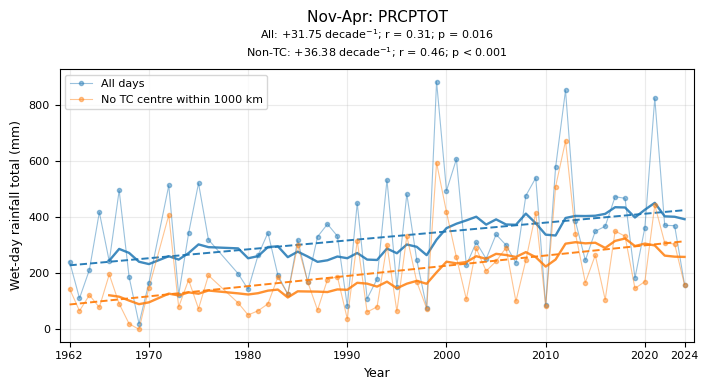

In [58]:
plot_single_index_timeseries(
    data=all_period_indices,
    trend_summary=full_trend_summary,
    index_name="PRCPTOT",
    period_type="Seasonal",
    period=DRY_SEASON_LABEL,
    output_path=DIAGNOSTIC_FIGURE_DIR / "nov_apr_prcptot.png",
    show_running_mean=SHOW_RUNNING_MEAN,
    rolling_window=ROLLING_WINDOW,
    annotate_stats=True,
    figsize=(7.2, 4.0),
)

Saved: /home/jupyter-bbr/source/science-garden-rainfall-trends/output/figures/diagnostic_timeseries/nov_apr_wd_rate.png


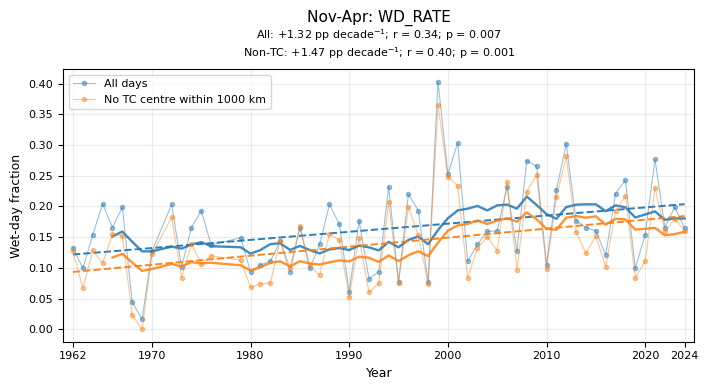

In [59]:
plot_single_index_timeseries(
    data=all_period_indices,
    trend_summary=full_trend_summary,
    index_name="WD_RATE",
    period_type="Seasonal",
    period=DRY_SEASON_LABEL,
    output_path=DIAGNOSTIC_FIGURE_DIR / "nov_apr_wd_rate.png",
    show_running_mean=SHOW_RUNNING_MEAN,
    rolling_window=ROLLING_WINDOW,
    annotate_stats=True,
    figsize=(7.2, 4.0),
)

Saved: /home/jupyter-bbr/source/science-garden-rainfall-trends/output/figures/diagnostic_timeseries/nov_apr_r20mm.png


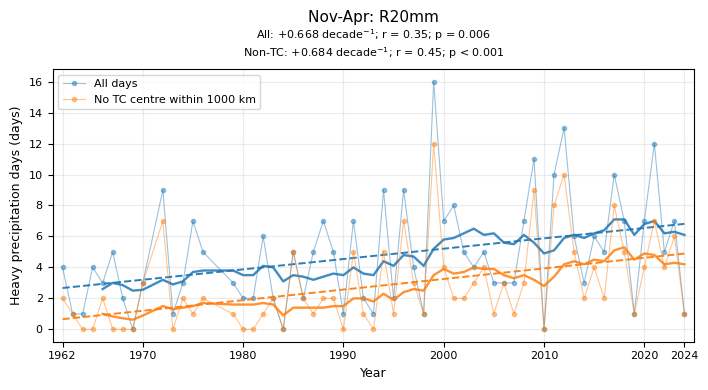

In [60]:
plot_single_index_timeseries(
    data=all_period_indices,
    trend_summary=full_trend_summary,
    index_name="R20mm",
    period_type="Seasonal",
    period=DRY_SEASON_LABEL,
    output_path=DIAGNOSTIC_FIGURE_DIR / "nov_apr_r20mm.png",
    show_running_mean=SHOW_RUNNING_MEAN,
    rolling_window=ROLLING_WINDOW,
    annotate_stats=True,
    figsize=(7.2, 4.0),
)

Saved: /home/jupyter-bbr/source/science-garden-rainfall-trends/output/figures/diagnostic_timeseries/nov_apr_cdd.png


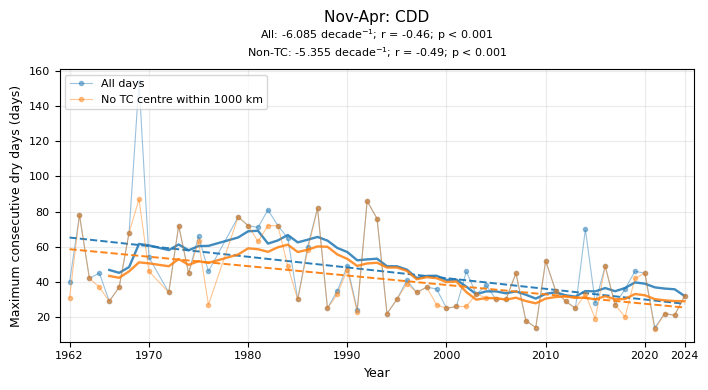

In [61]:
plot_single_index_timeseries(
    data=all_period_indices,
    trend_summary=full_trend_summary,
    index_name="CDD",
    period_type="Seasonal",
    period=DRY_SEASON_LABEL,
    output_path=DIAGNOSTIC_FIGURE_DIR / "nov_apr_cdd.png",
    show_running_mean=SHOW_RUNNING_MEAN,
    rolling_window=ROLLING_WINDOW,
    annotate_stats=True,
    figsize=(7.2, 4.0),
)

Saved: /home/jupyter-bbr/source/science-garden-rainfall-trends/output/figures/diagnostic_timeseries/nov_apr_mean_dry_spell_length.png


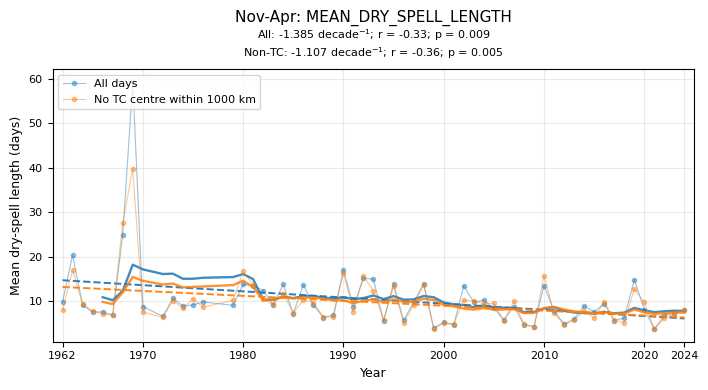

In [62]:
plot_single_index_timeseries(
    data=all_period_indices,
    trend_summary=full_trend_summary,
    index_name="MEAN_DRY_SPELL_LENGTH",
    period_type="Seasonal",
    period=DRY_SEASON_LABEL,
    output_path=DIAGNOSTIC_FIGURE_DIR / "nov_apr_mean_dry_spell_length.png",
    show_running_mean=SHOW_RUNNING_MEAN,
    rolling_window=ROLLING_WINDOW,
    annotate_stats=True,
    figsize=(7.2, 4.0),
)

Saved: /home/jupyter-bbr/source/science-garden-rainfall-trends/output/figures/diagnostic_timeseries/nov_apr_total_dry_spell_days_ge7.png


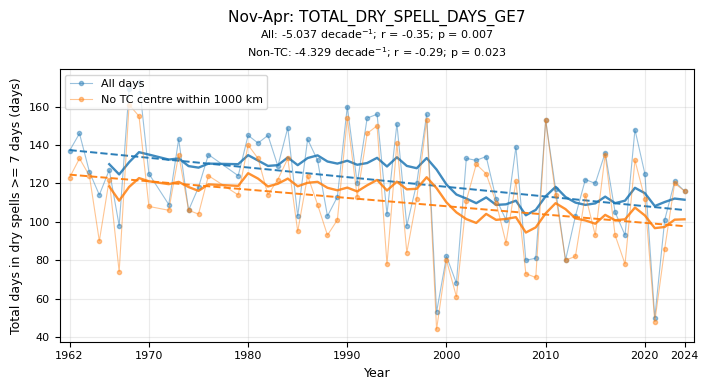

In [63]:
plot_single_index_timeseries(
    data=all_period_indices,
    trend_summary=full_trend_summary,
    index_name="TOTAL_DRY_SPELL_DAYS_GE7",
    period_type="Seasonal",
    period=DRY_SEASON_LABEL,
    output_path=DIAGNOSTIC_FIGURE_DIR / "nov_apr_total_dry_spell_days_ge7.png",
    show_running_mean=SHOW_RUNNING_MEAN,
    rolling_window=ROLLING_WINDOW,
    annotate_stats=True,
    figsize=(7.2, 4.0),
)